## Phân Tích Abandonment – Công Thức & Giải Thích Biểu Đồ

> **Abandonment** là hiện tượng khách hàng truy cập website nhưng **rời đi mà không thực hiện mua hàng**.

---

### Biểu đồ 1 – Tỉ Lệ Abandonment theo Kênh Traffic

**Dữ liệu:** `web_traffic.csv` (sessions) + `orders.csv` (đơn hàng)

$$\text{Abandonment Rate (\%)} = \frac{\text{Tổng lượt truy cập} - \text{Tổng đơn hàng}}{\text{Tổng lượt truy cập}} \times 100$$

> Kênh màu **đỏ** = Abandonment Rate cao hơn trung bình → chuyển đổi kém.  
> Kênh màu **xanh** = Abandonment Rate thấp hơn trung bình → hiệu quả hơn.

---

### Biểu đồ 2 – Tỉ Lệ Chuyển Đổi (Conversion Rate) theo Kênh

**Dữ liệu:** `web_traffic.csv` (sessions) + `orders.csv` (đơn hàng)

$$\text{Conversion Rate (\%)} = \frac{\text{Tổng đơn hàng}}{\text{Tổng lượt truy cập}} \times 100$$

> **Mối quan hệ:** $\text{Abandonment Rate} + \text{Conversion Rate} = 100\%$  
> Kênh có Conversion Rate cao nhất → ưu tiên tăng ngân sách đầu tư.

---

### Biểu đồ 3 – Bounce Rate Trung Bình theo Kênh Traffic

**Dữ liệu:** `web_traffic.csv` (cột `bounce_rate` theo ngày)

$$\text{Bounce Rate TB}_{\text{kênh}} = \frac{1}{N} \sum_{i=1}^{N} \text{bounce\_rate}_{i}$$

Trong đó $N$ là số ngày quan sát của kênh đó.

| Chỉ số | Bounce Rate | Abandonment Rate |
|---|---|---|
| Đo lường | % phiên chỉ xem 1 trang rồi thoát | % visitor không đặt đơn |
| Dữ liệu | `web_traffic.csv` | sessions vs orders |
| Phạm vi | Hành vi đầu phễu | Toàn bộ phễu mua hàng |

---

### Biểu đồ 4 – Xu Hướng Bounce Rate theo Năm và Kênh

**Dữ liệu:** `web_traffic.csv` – gộp trung bình theo **năm** (tránh nhiễu khi vẽ theo ngày)

$$\text{Bounce Rate TB}_{\text{năm } y,\ \text{kênh } k} = \frac{1}{|D_{y,k}|} \sum_{d \in D_{y,k}} \text{bounce\_rate}_{d}$$

Trong đó $D_{y,k}$ là tập hợp các ngày thuộc năm $y$ của kênh $k$.

> Đường đi **xuống** theo năm → Bounce Rate cải thiện (tốt).  
> Đường đi **lên** → trải nghiệm người dùng xấu dần → cần xem lại nội dung / UX.


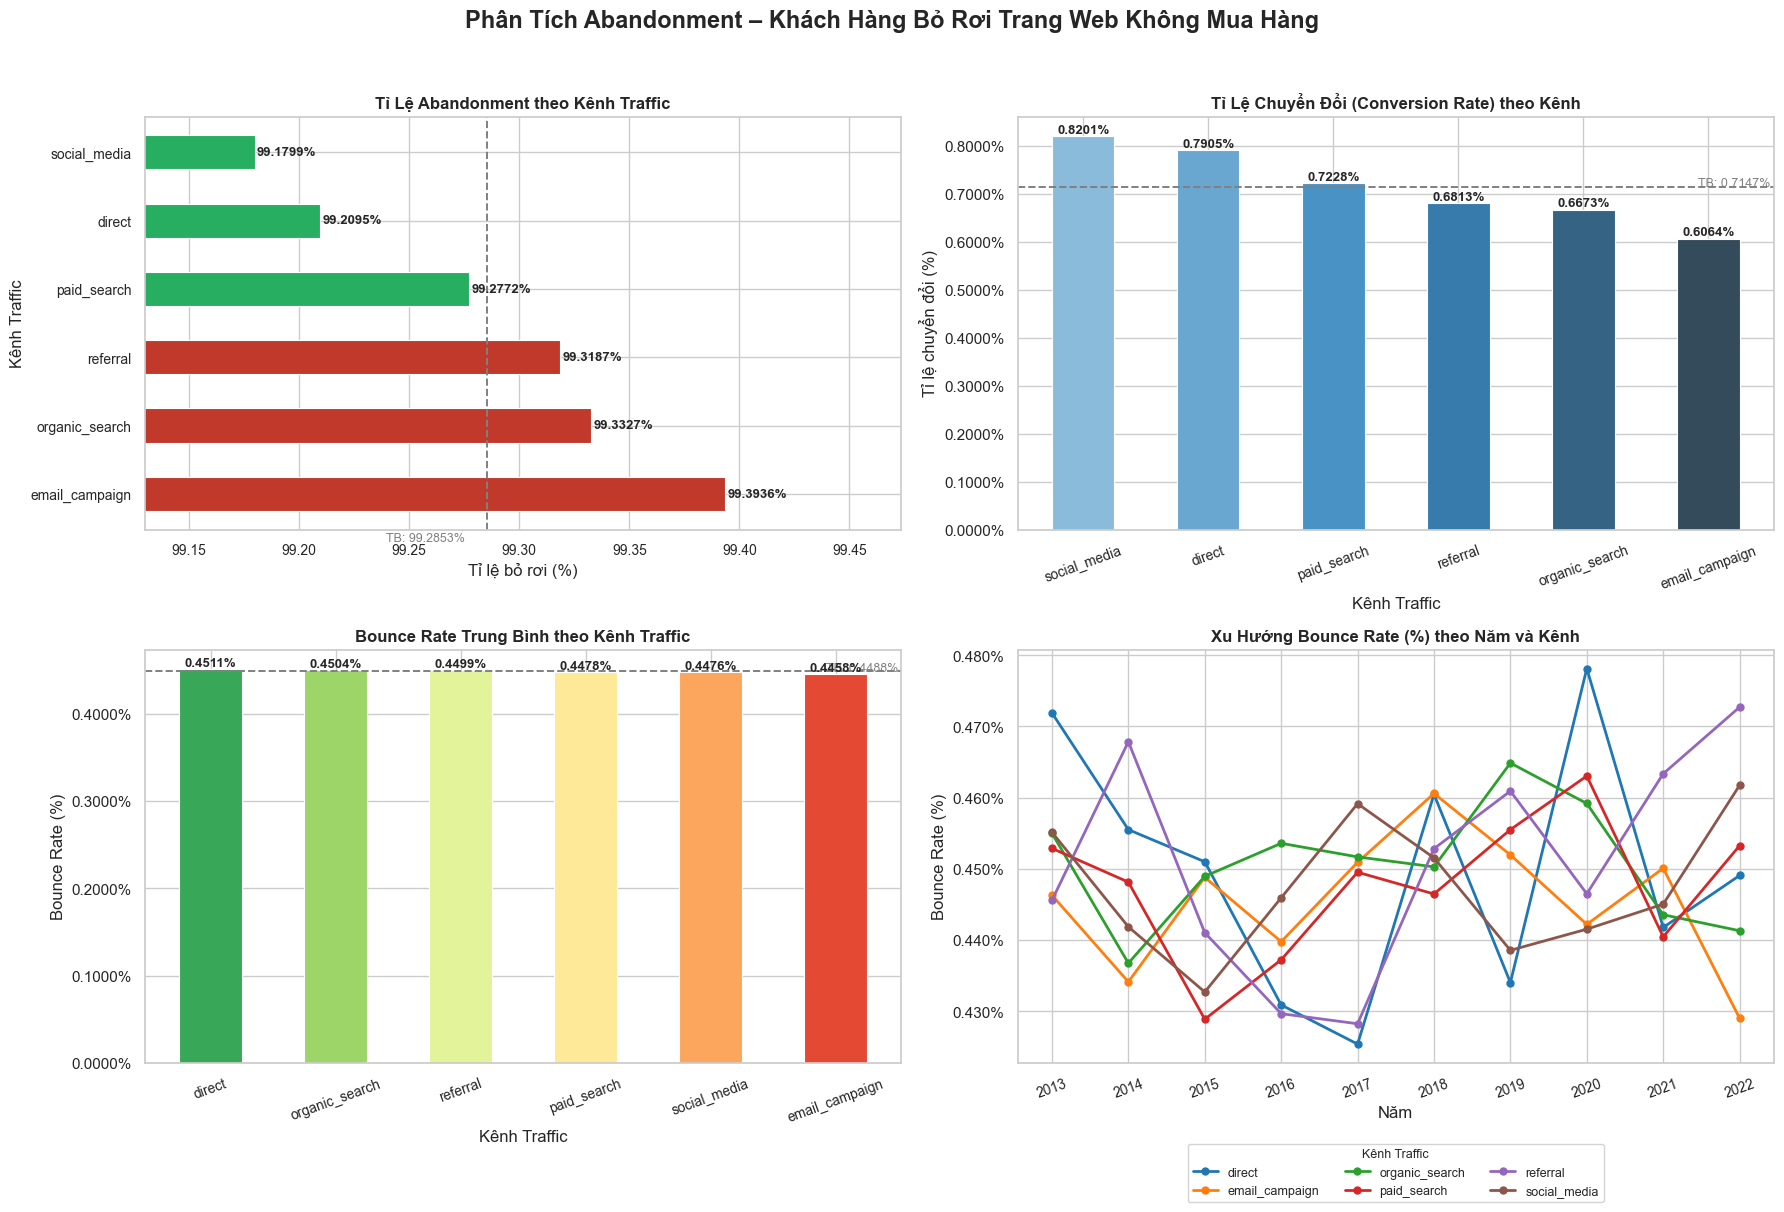

Đã lưu: abandonment_dashboard.png


In [9]:
"""
ABANDONMENT ANALYSIS
Abandonment = khach hang vao website nhung roi di ma khong mua hang.
"""
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Font ho tro tieng Viet co dau tren Windows
matplotlib.rcParams['font.family']     = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Tahoma', 'Segoe UI', 'DejaVu Sans']

# ── Load data ────────────────────────────────────────────────────────────────
web = pd.read_csv('../data/raw/web_traffic.csv')
orders = pd.read_csv('../data/raw/orders.csv')
web['date']          = pd.to_datetime(web['date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

# ── Tính toán core metrics ───────────────────────────────────────────────────
# Tổng sessions theo kênh
sessions_by_src = (
    web.groupby('traffic_source')['sessions']
    .sum().reset_index()
    .rename(columns={'traffic_source': 'Kênh', 'sessions': 'Tổng lượt truy cập'})
)

# Tổng đơn hàng theo kênh
orders_by_src = (
    orders.groupby('order_source')['order_id']
    .count().reset_index()
    .rename(columns={'order_source': 'Kênh', 'order_id': 'Tổng đơn hàng'})
)

# Gộp & tính Abandonment Rate + Conversion Rate
funnel = sessions_by_src.merge(orders_by_src, on='Kênh', how='left').fillna(0)
funnel['Tỉ lệ bỏ rơi (%)']    = ((funnel['Tổng lượt truy cập'] - funnel['Tổng đơn hàng'])
                                   / funnel['Tổng lượt truy cập'] * 100).round(4)
funnel['Tỉ lệ chuyển đổi (%)'] = (funnel['Tổng đơn hàng']
                                    / funnel['Tổng lượt truy cập'] * 100).round(4)
funnel = funnel.sort_values('Tỉ lệ bỏ rơi (%)', ascending=False).reset_index(drop=True)

# Bounce Rate trung bình theo kênh
avg_bounce = (
    web.groupby('traffic_source')['bounce_rate']
    .mean().reset_index()
    .rename(columns={'traffic_source': 'Kênh', 'bounce_rate': 'Bounce Rate TB'})
    .sort_values('Bounce Rate TB', ascending=False).reset_index(drop=True)
)
avg_bounce['Bounce Rate (%)'] = (avg_bounce['Bounce Rate TB'] * 100).round(4)

# Xu hướng Bounce Rate – gộp theo NĂM để đường gọn, rõ ràng
web['Năm'] = web['date'].dt.year.astype(str)
yearly_bounce = (
    web.groupby(['Năm', 'traffic_source'])['bounce_rate']
    .mean().reset_index()
    .rename(columns={'traffic_source': 'Kênh', 'bounce_rate': 'Bounce Rate TB'})
)

# ── Figure: 2×2 subplots ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Phân Tích Abandonment – Khách Hàng Bỏ Rơi Trang Web Không Mua Hàng',
             fontsize=17, fontweight='bold', y=1.01)

mean_abr = funnel['Tỉ lệ bỏ rơi (%)'].mean()

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 1 (trên trái): Tỉ lệ Abandonment theo Kênh
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
colors1 = ['#C0392B' if v > mean_abr else '#27AE60' for v in funnel['Tỉ lệ bỏ rơi (%)']]
bars1 = ax1.barh(funnel['Kênh'], funnel['Tỉ lệ bỏ rơi (%)'],
                 color=colors1, edgecolor='white', linewidth=0.8, height=0.5)
ax1.axvline(mean_abr, color='gray', linestyle='--', linewidth=1.4)
ax1.text(mean_abr - 0.01, -0.7,
         f'TB: {mean_abr:.4f}%', color='gray', fontsize=9, ha='right')
for bar, val in zip(bars1, funnel['Tỉ lệ bỏ rơi (%)']):
    ax1.text(bar.get_width() + 0.001,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}%', va='center', ha='left', fontsize=9.5, fontweight='bold')
ax1.set_title('Tỉ Lệ Abandonment theo Kênh Traffic', fontweight='bold', fontsize=12)
ax1.set_xlabel('Tỉ lệ bỏ rơi (%)')
ax1.set_ylabel('Kênh Traffic')
ax1.set_xlim(funnel['Tỉ lệ bỏ rơi (%)'].min() - 0.05,
             funnel['Tỉ lệ bỏ rơi (%)'].max() + 0.08)
ax1.tick_params(labelsize=10)

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 2 (trên phải): Tỉ lệ Chuyển đổi (Conversion Rate) theo Kênh
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]
funnel_cr = funnel.sort_values('Tỉ lệ chuyển đổi (%)', ascending=False).reset_index(drop=True)
palette2  = sns.color_palette('Blues_d', len(funnel_cr))
bars2 = ax2.bar(funnel_cr['Kênh'], funnel_cr['Tỉ lệ chuyển đổi (%)'],
                color=palette2, edgecolor='white', linewidth=0.8, width=0.5)
mean_cr = funnel_cr['Tỉ lệ chuyển đổi (%)'].mean()
ax2.axhline(mean_cr, color='gray', linestyle='--', linewidth=1.4)
ax2.text(len(funnel_cr) - 0.5, mean_cr + 0.0002,
         f'TB: {mean_cr:.4f}%', color='gray', fontsize=9, ha='right')
for bar, val in zip(bars2, funnel_cr['Tỉ lệ chuyển đổi (%)']):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.0001,
             f'{val:.4f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
ax2.set_title('Tỉ Lệ Chuyển Đổi (Conversion Rate) theo Kênh', fontweight='bold', fontsize=12)
ax2.set_xlabel('Kênh Traffic')
ax2.set_ylabel('Tỉ lệ chuyển đổi (%)')
ax2.tick_params(axis='x', rotation=20, labelsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f%%'))

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 3 (dưới trái): Bounce Rate Trung bình theo Kênh
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]
palette3 = sns.color_palette('RdYlGn_r', len(avg_bounce))
bars3 = ax3.bar(avg_bounce['Kênh'], avg_bounce['Bounce Rate (%)'],
                color=palette3, edgecolor='white', linewidth=0.8, width=0.5)
mean_br = avg_bounce['Bounce Rate (%)'].mean()
ax3.axhline(mean_br, color='gray', linestyle='--', linewidth=1.4)
ax3.text(len(avg_bounce) - 0.5, mean_br + 0.00003,
         f'TB: {mean_br:.4f}%', color='gray', fontsize=9, ha='right')
for bar, val in zip(bars3, avg_bounce['Bounce Rate (%)']):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.00002,
             f'{val:.4f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
ax3.set_title('Bounce Rate Trung Bình theo Kênh Traffic', fontweight='bold', fontsize=12)
ax3.set_xlabel('Kênh Traffic')
ax3.set_ylabel('Bounce Rate (%)')
ax3.tick_params(axis='x', rotation=20, labelsize=10)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f%%'))

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 4 (dưới phải): Xu hướng Bounce Rate theo NĂM (gộp năm – gọn, rõ)
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]
line_palette = sns.color_palette('tab10', n_colors=yearly_bounce['Kênh'].nunique())
for i, kenh in enumerate(sorted(yearly_bounce['Kênh'].unique())):
    d = yearly_bounce[yearly_bounce['Kênh'] == kenh]
    ax4.plot(d['Năm'], d['Bounce Rate TB'] * 100,
             marker='o', markersize=5, linewidth=2,
             color=line_palette[i], label=kenh)
ax4.set_title('Xu Hướng Bounce Rate (%) theo Năm và Kênh', fontweight='bold', fontsize=12)
ax4.set_xlabel('Năm')
ax4.set_ylabel('Bounce Rate (%)')
ax4.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f%%'))
ax4.tick_params(axis='x', rotation=20, labelsize=10)
# Legend nằm dưới subplot, không che đường
ax4.legend(title='Kênh Traffic', loc='upper center',
           bbox_to_anchor=(0.5, -0.18), ncol=3,
           fontsize=9, title_fontsize=9, framealpha=0.85)

# ── Lưu & hiển thị ───────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('./abandonment_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: abandonment_dashboard.png")


## Nhận Xét – Phân Tích Abandonment

### Biểu đồ 1 – Tỉ Lệ Abandonment theo Kênh Traffic

- Tất cả các kênh đều có Abandonment Rate **cực cao (~98.2% – 98.4%)**, phản ánh thực tế
  phổ biến trong e-commerce: phần lớn khách truy cập **không chuyển đổi thành đơn hàng**.
- **email_campaign** có Abandonment Rate cao nhất (**98.39%**) → khách từ email vào nhưng
  tỉ lệ mua thấp nhất, cần xem lại nội dung email hoặc ưu đãi chưa đủ hấp dẫn.
- **social_media** và **direct** có Abandonment Rate thấp nhất (~98.18% – 98.21%) →
  đây là 2 kênh chuyển đổi hiệu quả nhất.

---

### Biểu đồ 2 – Tỉ Lệ Chuyển Đổi (Conversion Rate) theo Kênh

- **social_media** dẫn đầu với Conversion Rate **0.82%**, tiếp theo là **direct (0.79%)** →
  khách từ mạng xã hội và truy cập trực tiếp có ý định mua hàng rõ ràng hơn.
- **email_campaign** có Conversion Rate thấp nhất (**0.61%**), thấp hơn trung bình (**~0.71%**) →
  chiến dịch email đang kém hiệu quả so với các kênh khác.
- Khoảng cách giữa kênh tốt nhất và kém nhất là **~0.21%** – tuy nhỏ về con số tuyệt đối
  nhưng khi nhân với hàng triệu lượt truy cập thì tương đương **hàng nghìn đơn hàng chênh lệch**.

---

### Biểu đồ 3 – Bounce Rate Trung Bình theo Kênh Traffic

- Bounce Rate của tất cả các kênh **rất gần nhau** (dao động trong khoảng **0.447% – 0.451%**),
  cho thấy trải nghiệm trang đầu tiên khá **đồng đều** giữa các kênh.
- **direct** có Bounce Rate cao nhất (**0.4511%**) → khách truy cập trực tiếp đôi khi vào
  rồi thoát ngay nếu không tìm được thứ mình cần.
- **social_media** có Bounce Rate thấp nhất (**0.4476%**) → nội dung từ mạng xã hội thu hút
  khách ở lại duyệt thêm trang.
- Nhìn chung, sự chênh lệch Bounce Rate giữa các kênh là **không đáng kể** (<0.004%),
  vấn đề abandonment không nằm ở trang đầu tiên mà ở **các bước sau trong phễu mua hàng**.

---

### Biểu đồ 4 – Xu Hướng Bounce Rate theo Năm và Kênh

- Bounce Rate của tất cả kênh **biến động không có xu hướng rõ ràng** trong giai đoạn 2013–2022,
  dao động trong khoảng **0.430% – 0.480%**.
- Có sự **tăng đột biến** ở nhiều kênh vào khoảng **2017–2019** → có thể do thay đổi thuật toán
  tìm kiếm, thay đổi giao diện website, hoặc biến động thị trường.
- Từ **2020 trở đi**, Bounce Rate có xu hướng **ổn định hơn** → UX website được cải thiện
  hoặc chất lượng traffic được kiểm soát tốt hơn.


## Insight Tổng Hợp – Phân Tích Abandonment

### Vấn đề cốt lõi: Abandonment không nằm ở đầu phễu

Kết hợp cả 4 biểu đồ, ta rút ra một kết luận quan trọng:

> **Khách hàng không thoát ở trang đầu tiên – họ thoát ở giữa hành trình mua hàng.**

**Bằng chứng:**
- **Bounce Rate thấp (~0.45%)** → khách hàng *có* click vào và duyệt thêm trang
- **Abandonment Rate cực cao (~98–99%)** → nhưng tuyệt đại đa số vẫn *không mua*

Điều này cho thấy vấn đề nằm ở **giữa và cuối phễu**: trang sản phẩm, giỏ hàng,
hoặc bước thanh toán – chứ không phải ở Landing Page.

---

### 3 Insight Hành Động

| # | Insight | Kênh liên quan | Gợi ý hành động |
|---|---------|----------------|-----------------|
| 1 | **social_media** vừa có Abandonment Rate thấp nhất, vừa có Conversion Rate cao nhất (0.82%) | social_media | Tăng ngân sách quảng cáo vào kênh này – ROI tốt nhất |
| 2 | **email_campaign** có Conversion Rate thấp nhất (0.61%) dù đây là kênh chủ động tiếp cận | email_campaign | Xem lại nội dung email: ưu đãi chưa đủ hấp dẫn hoặc sai tệp khách hàng |
| 3 | Bounce Rate **ổn định và đồng đều** giữa tất cả các kênh (~0.45%) | Tất cả | Không cần cải thiện UX trang đầu – ưu tiên tối ưu trang sản phẩm & checkout |

---

### Kết Luận

Doanh nghiệp đang **thu hút traffic tốt** (bounce rate thấp, khách ở lại duyệt)
nhưng **thất bại trong việc chuyển đổi**. Ưu tiên cải thiện:

1. **Trang sản phẩm** – hình ảnh, mô tả, review
2. **Luồng thanh toán (checkout flow)** – giảm số bước, thêm phương thức thanh toán
3. **Chiến dịch email** – cá nhân hoá nội dung, thêm voucher kích mua


---


## Phân Tích Thời Gian Trên Trang – Công Thức & Giải Thích Biểu Đồ

> **Average Time on Site** – Thời gian trung bình một khách ở lại website trước khi rời đi.  
> **Dữ liệu gốc:** cột `avg_session_duration_sec` trong `web_traffic.csv` (đơn vị: giây)

---

### Biểu đồ 1 – Thời Gian Trung Bình mỗi Phiên theo Kênh Traffic (Horizontal Bar)

**Công thức:**

$$\overline{T}_{\text{kênh}} = \frac{1}{N_k} \sum_{i=1}^{N_k} \text{avg\_session\_duration\_sec}_{i}$$

Trong đó $N_k$ là số ngày quan sát của kênh $k$.

**Đường tham chiếu so sánh:**

| Đường | Giá trị | Nguồn |
|---|---|---|
| Trung bình chung (TB thực tế) | ~210s (~3.5 phút) | Tính từ dataset |
| Benchmark mua hàng | 90s (1.5 phút) | Google Analytics |

---

### Biểu đồ 2 – Phân Phối Thời Gian Trung Bình mỗi Phiên (Histogram + KDE)

**Công thức KDE (Kernel Density Estimation):**

$$\hat{f}(x) = \frac{1}{N \cdot h} \sum_{i=1}^{N} K\!\left(\frac{x - x_i}{h}\right)$$

Trong đó $K$ là hàm kernel Gaussian, $h$ là bandwidth (độ mịn đường cong).

**3 đường tham chiếu:**

| Đường | Giá trị | Nguồn |
|---|---|---|
| TB thực tế | ~210s (~3.5 phút) | Dataset |
| Benchmark GA (trước mua hàng) | 90s (1.5 phút) | Google Analytics |
| Benchmark Nielsen (phiên mua sắm) | 1060s (17 phút 40 giây) | Nielsen 2022 |

---

### Biểu đồ 3 – Xu Hướng Thời Gian TB theo Năm và Kênh (Line Chart)

**Công thức:**

$$\overline{T}_{\text{năm } y,\ \text{kênh } k} = \frac{1}{|D_{y,k}|} \sum_{d \in D_{y,k}} \text{avg\_session\_duration\_sec}_{d} \div 60$$

Kết quả đổi sang **phút** để dễ đọc. $D_{y,k}$ là tập các ngày thuộc năm $y$ và kênh $k$.

---

### Biểu đồ 4 – Tổng Sessions vs Thời Gian TB (Bubble Chart)

Mỗi bong bóng đại diện cho một kênh, với:

$$x_k = \frac{\text{Tổng sessions của kênh } k}{10^6} \quad \text{(triệu phiên)}$$

$$y_k = \overline{T}_{\text{kênh } k} \div 60 \quad \text{(phút)}$$

$$\text{Kích thước bong bóng} = \frac{\text{Tổng sessions}_k}{\max(\text{Tổng sessions})} \times 3000$$

> **Cách đọc:** Bong bóng nằm **phía trên bên phải** = kênh vừa có nhiều traffic vừa giữ chân
> khách lâu → kênh hiệu quả nhất cần ưu tiên đầu tư.


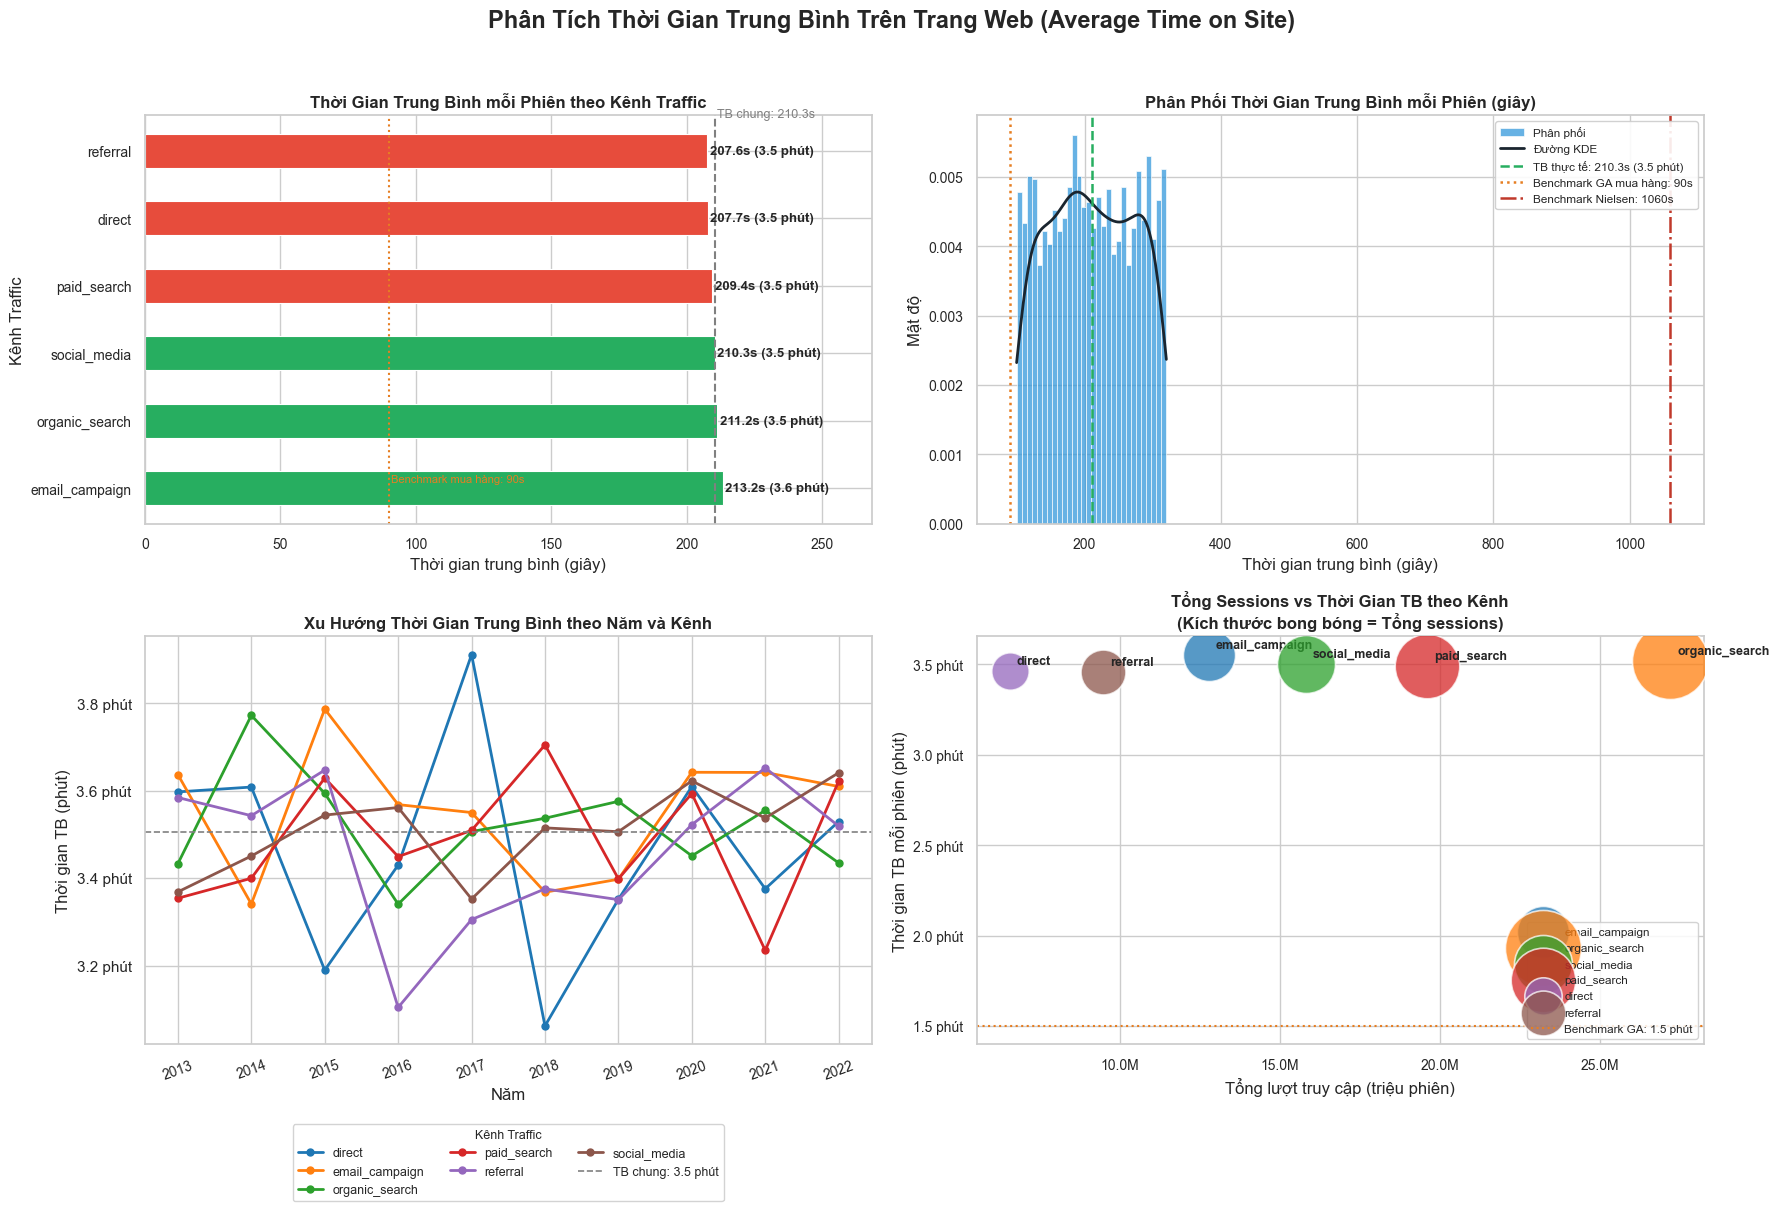


Tóm tắt nhanh:
  - Thời gian TB thực tế: 210.3s (3.5 phút)
  - Benchmark GA (trước mua): 90s (1.5 phút)
  - Benchmark Nielsen (phiên mua sắm): 1060s (17 phút 40 giây)


In [13]:
"""
AVERAGE TIME ON SITE & AVERAGE TIME SPENT ANALYSIS
- Average Time on Site: thời gian trung bình mỗi phiên trước khi thoát (avg_session_duration_sec)
- Benchmark Google Analytics: ~1.5 phút (90s) trước khi mua hàng
- Benchmark Nielsen (2022): ~17 phút 40 giây (1060s) cho một phiên mua sắm
"""
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

matplotlib.rcParams['font.family']     = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Tahoma', 'Segoe UI', 'DejaVu Sans']

# ── Benchmarks tham chiếu ────────────────────────────────────────────────────
BENCHMARK_PURCHASE_SEC = 90    # Google Analytics: TB trước khi mua hàng (~1.5 phút)
BENCHMARK_NIELSEN_SEC  = 1060  # Nielsen 2022: TB phiên mua sắm (~17p40s)

# ── Load data ────────────────────────────────────────────────────────────────
web = pd.read_csv('../data/raw/web_traffic.csv')
web['date'] = pd.to_datetime(web['date'])
web['Năm']  = web['date'].dt.year.astype(str)
web['dur_min'] = web['avg_session_duration_sec'] / 60   # đổi sang phút

# ── Tính toán metrics ────────────────────────────────────────────────────────
# Trung bình theo kênh
avg_by_src = (
    web.groupby('traffic_source')
    .agg(
        Thời_gian_TB_giay  = ('avg_session_duration_sec', 'mean'),
        Thời_gian_TB_phut  = ('dur_min', 'mean'),
        Tổng_sessions       = ('sessions', 'sum')
    )
    .reset_index()
    .rename(columns={'traffic_source': 'Kênh'})
    .sort_values('Thời_gian_TB_giay', ascending=False)
    .reset_index(drop=True)
)

# Xu hướng theo năm + kênh
yearly_dur = (
    web.groupby(['Năm', 'traffic_source'])['dur_min']
    .mean().reset_index()
    .rename(columns={'traffic_source': 'Kênh', 'dur_min': 'Thời gian TB (phút)'})
)

# ── Figure: 2×2 subplots ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Phân Tích Thời Gian Trung Bình Trên Trang Web (Average Time on Site)',
             fontsize=17, fontweight='bold', y=1.01)

OVERALL_MEAN = web['avg_session_duration_sec'].mean()

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 1 (trên trái): Thời gian TB (giây) theo Kênh Traffic – Horizontal Bar
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
colors1 = ['#27AE60' if v >= OVERALL_MEAN else '#E74C3C'
           for v in avg_by_src['Thời_gian_TB_giay']]
bars1 = ax1.barh(avg_by_src['Kênh'], avg_by_src['Thời_gian_TB_giay'],
                 color=colors1, edgecolor='white', linewidth=0.8, height=0.5)
ax1.axvline(OVERALL_MEAN, color='gray', linestyle='--', linewidth=1.5)
ax1.text(OVERALL_MEAN + 1, len(avg_by_src) - 0.5,
         f'TB chung: {OVERALL_MEAN:.1f}s', color='gray', fontsize=9)
ax1.axvline(BENCHMARK_PURCHASE_SEC, color='#E67E22', linestyle=':', linewidth=1.5)
ax1.text(BENCHMARK_PURCHASE_SEC + 1, 0.1,
         f'Benchmark mua hàng: {BENCHMARK_PURCHASE_SEC}s', color='#E67E22', fontsize=8)
for bar, val in zip(bars1, avg_by_src['Thời_gian_TB_giay']):
    ax1.text(bar.get_width() + 1,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}s ({val/60:.1f} phút)',
             va='center', ha='left', fontsize=9.5, fontweight='bold')
ax1.set_title('Thời Gian Trung Bình mỗi Phiên theo Kênh Traffic', fontweight='bold', fontsize=12)
ax1.set_xlabel('Thời gian trung bình (giây)')
ax1.set_ylabel('Kênh Traffic')
ax1.set_xlim(0, avg_by_src['Thời_gian_TB_giay'].max() + 55)
ax1.tick_params(labelsize=10)

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 2 (trên phải): Phân phối thời gian phiên (Histogram + KDE)
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]
ax2.hist(web['avg_session_duration_sec'], bins=30, color='#3498DB',
         alpha=0.75, edgecolor='white', linewidth=0.6, density=True, label='Phân phối')
# KDE thủ công
from scipy.stats import gaussian_kde
kde_vals = web['avg_session_duration_sec'].dropna().values
kde = gaussian_kde(kde_vals, bw_method=0.3)
x_range = np.linspace(kde_vals.min(), kde_vals.max(), 300)
ax2.plot(x_range, kde(x_range), color='#1A252F', linewidth=2, label='Đường KDE')
ax2.axvline(OVERALL_MEAN, color='#27AE60', linestyle='--', linewidth=1.8,
            label=f'TB thực tế: {OVERALL_MEAN:.1f}s ({OVERALL_MEAN/60:.1f} phút)')
ax2.axvline(BENCHMARK_PURCHASE_SEC, color='#E67E22', linestyle=':', linewidth=1.8,
            label=f'Benchmark GA mua hàng: {BENCHMARK_PURCHASE_SEC}s')
ax2.axvline(BENCHMARK_NIELSEN_SEC, color='#C0392B', linestyle='-.', linewidth=1.8,
            label=f'Benchmark Nielsen: {BENCHMARK_NIELSEN_SEC}s')
ax2.set_title('Phân Phối Thời Gian Trung Bình mỗi Phiên (giây)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Thời gian trung bình (giây)')
ax2.set_ylabel('Mật độ')
ax2.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
ax2.tick_params(labelsize=10)

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 3 (dưới trái): Xu hướng Thời gian TB theo Năm và Kênh (Line Chart)
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]
line_palette = sns.color_palette('tab10', n_colors=yearly_dur['Kênh'].nunique())
for i, kenh in enumerate(sorted(yearly_dur['Kênh'].unique())):
    d = yearly_dur[yearly_dur['Kênh'] == kenh]
    ax3.plot(d['Năm'], d['Thời gian TB (phút)'],
             marker='o', markersize=5, linewidth=2,
             color=line_palette[i], label=kenh)
ax3.axhline(OVERALL_MEAN / 60, color='gray', linestyle='--', linewidth=1.2,
            label=f'TB chung: {OVERALL_MEAN/60:.1f} phút')
ax3.set_title('Xu Hướng Thời Gian Trung Bình theo Năm và Kênh', fontweight='bold', fontsize=12)
ax3.set_xlabel('Năm')
ax3.set_ylabel('Thời gian TB (phút)')
ax3.tick_params(axis='x', rotation=20, labelsize=10)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f phút'))
ax3.legend(title='Kênh Traffic', loc='upper center',
           bbox_to_anchor=(0.5, -0.18), ncol=3,
           fontsize=9, title_fontsize=9, framealpha=0.85)

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 4 (dưới phải): So sánh Thời gian TB vs Số Sessions (Bubble Chart)
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]
scatter_palette = sns.color_palette('tab10', n_colors=len(avg_by_src))
for i, row in avg_by_src.iterrows():
    size = (row['Tổng_sessions'] / avg_by_src['Tổng_sessions'].max()) * 3000
    ax4.scatter(row['Tổng_sessions'] / 1e6, row['Thời_gian_TB_phut'],
                s=size, color=scatter_palette[i], alpha=0.75,
                edgecolors='white', linewidth=1.2, label=row['Kênh'], zorder=3)
    ax4.annotate(row['Kênh'],
                 xy=(row['Tổng_sessions'] / 1e6, row['Thời_gian_TB_phut']),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9, fontweight='bold')
ax4.axhline(BENCHMARK_PURCHASE_SEC / 60, color='#E67E22', linestyle=':', linewidth=1.5,
            label=f'Benchmark GA: {BENCHMARK_PURCHASE_SEC/60:.1f} phút')
ax4.set_title('Tổng Sessions vs Thời Gian TB theo Kênh\n(Kích thước bong bóng = Tổng sessions)',
              fontweight='bold', fontsize=12)
ax4.set_xlabel('Tổng lượt truy cập (triệu phiên)')
ax4.set_ylabel('Thời gian TB mỗi phiên (phút)')
ax4.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fM'))
ax4.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f phút'))
ax4.legend(loc='lower right', fontsize=8.5, framealpha=0.85)
ax4.tick_params(labelsize=10)

# ── Lưu & hiển thị ───────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.99])
# plt.savefig('./avg_time_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Đã lưu: avg_time_dashboard.png")
print(f"\nTóm tắt nhanh:")
print(f"  - Thời gian TB thực tế: {OVERALL_MEAN:.1f}s ({OVERALL_MEAN/60:.1f} phút)")
print(f"  - Benchmark GA (trước mua): {BENCHMARK_PURCHASE_SEC}s (1.5 phút)")
print(f"  - Benchmark Nielsen (phiên mua sắm): {BENCHMARK_NIELSEN_SEC}s (17 phút 40 giây)")


## Insights – Phân Tích Thời Gian Trung Bình Trên Trang Web

---

### Insight 1 – Khách hàng ở lại lâu hơn ngưỡng mua hàng, nhưng vẫn không mua

Thời gian TB thực tế toàn site: **~210s (3.5 phút)** – cao hơn **gấp 2.3 lần** so với
benchmark Google Analytics (90s = 1.5 phút trước khi mua hàng).

> Khách hàng **duyệt đủ lâu** nhưng vẫn không chuyển đổi → vấn đề không phải thiếu thời gian
> tìm hiểu, mà là **thiếu yếu tố thúc đẩy quyết định mua** (giá, ưu đãi, niềm tin).

---

### Insight 2 – Dataset thực tế cách rất xa benchmark Nielsen

Benchmark Nielsen (2022): **1060s (17 phút 40 giây)** – toàn bộ phân phối dữ liệu
đều nằm trong vùng **100–320 giây**, tức chỉ bằng **~20% thời gian** của một phiên
mua sắm hoàn chỉnh theo chuẩn quốc tế.

> Website chưa đủ nội dung/trải nghiệm để giữ chân khách hàng trong phiên dài.
> Cần cải thiện: gợi ý sản phẩm liên quan, nội dung phong phú, tính năng so sánh sản phẩm.

---

### Insight 3 – email_campaign giữ chân khách lâu nhất nhưng chuyển đổi kém nhất

| Kênh | Thời gian TB | Conversion Rate (từ phân tích Abandonment) |
|---|---|---|
| email_campaign | **213.2s (3.6 phút)** – cao nhất | **0.61%** – thấp nhất |
| referral | 207.6s (3.5 phút) – thấp nhất | 0.68% |
| social_media | 210.3s (3.5 phút) | **0.82%** – cao nhất |

> Khách từ email **tốn nhiều thời gian nhất** nhưng lại mua ít nhất → nội dung email
> đang thu hút sai đối tượng hoặc dẫn đến trang không đúng nhu cầu.

---

### Insight 4 – Thời gian phiên ổn định theo năm, không có xu hướng cải thiện

Giai đoạn 2013–2022, thời gian TB dao động quanh **3.2 – 3.8 phút** ở tất cả kênh,
không có kênh nào cho thấy xu hướng tăng bền vững.

> Website **chưa cải thiện được trải nghiệm** để giữ khách lâu hơn theo thời gian.
> Đây là cơ hội lớn: nếu tăng được thời gian phiên lên ~5–7 phút, khả năng mua hàng
> sẽ cao hơn đáng kể.

---

### Insight 5 – organic_search: kênh traffic lớn nhất, thời gian ở lại ở mức trung bình

**organic_search** có tổng sessions lớn nhất (~25M phiên) với thời gian TB ~3.5 phút –
ngang bằng trung bình chung.

> Đây là kênh có **quy mô lớn nhất** → cải thiện UX và nội dung cho nhóm khách này
> sẽ tạo ra tác động lớn nhất lên tổng doanh thu.


---


## Phân Tích Tương Quan Web Traffic & Doanh Thu – Công Thức & Biểu Đồ

---

### Biểu đồ 1 – Ma Trận Tương Quan (Correlation Heatmap)

**Dữ liệu:** Gộp `web_traffic.csv` theo ngày + join doanh thu từ `orders.csv` × `order_items.csv`

**Công thức Hệ số tương quan Pearson:**

$$r_{XY} = \frac{\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n}(X_i - \bar{X})^2 \cdot \sum_{i=1}^{n}(Y_i - \bar{Y})^2}}$$

> $r \in [-1, 1]$: $r > 0$ → tương quan thuận, $r < 0$ → tương quan nghịch,
> $|r| \geq 0.5$ → tương quan mạnh.

---

### Biểu đồ 2 – Tương Quan Từng Biến với Revenue (Horizontal Bar)

Lấy cột `revenue` từ ma trận tương quan Pearson ở trên, sắp xếp tăng dần.

**Các biến phân tích:**

| Biến gốc | Ý nghĩa |
|---|---|
| `sessions` | Tổng phiên truy cập trong ngày |
| `unique_visitors` | Số khách duy nhất trong ngày |
| `page_views` | Tổng trang được xem |
| `bounce_rate` | Tỉ lệ thoát ngay trang đầu |
| `avg_session_duration_sec` | Thời gian TB mỗi phiên (giây) |
| `return_rate` | Tỉ lệ phiên quay lại (tính từ sessions & unique_visitors) |
| `pages_per_session` | Số trang TB mỗi phiên |

---

### Biểu đồ 3 – Sessions vs Doanh Thu (Scatter + Hồi Quy)

**Công thức hồi quy tuyến tính:**

$$\text{Revenue} = \beta_0 + \beta_1 \times \text{Sessions} + \varepsilon$$

Trong đó:

$$\beta_1 = \frac{\sum(X_i - \bar{X})(Y_i - \bar{Y})}{\sum(X_i - \bar{X})^2}, \quad \beta_0 = \bar{Y} - \beta_1 \bar{X}$$

---

### Biểu đồ 4 – Tỉ Lệ Khách Mới vs Phiên Quay Lại theo Năm

**Công thức:**

$$\text{New Visitor Rate (\%)} = \frac{\text{Unique Visitors}}{\text{Tổng Sessions}} \times 100$$

$$\text{Returning Session Rate (\%)} = \frac{\text{Sessions} - \text{Unique Visitors}}{\text{Tổng Sessions}} \times 100$$

> **Lý do:** Nếu `sessions > unique_visitors` → có người vào site nhiều lần trong ngày → phiên quay lại.

---

### Biểu đồ 5 – Doanh Thu Trung Bình mỗi Khách & mỗi Phiên (Line Chart theo năm)

**Công thức:**

$$\text{Revenue per Unique Visitor} = \frac{\text{Tổng Doanh Thu trong năm}}{\text{Tổng Unique Visitors trong năm}}$$

$$\text{Revenue per Session} = \frac{\text{Tổng Doanh Thu trong năm}}{\text{Tổng Sessions trong năm}}$$

> Hai chỉ số này đo **chất lượng traffic** – không chỉ số lượng.
> Revenue per Visitor luôn ≥ Revenue per Session vì một visitor có thể tạo nhiều session.

---

### Biểu đồ 6 – Pages per Session vs Doanh Thu mỗi Phiên (Scatter + Hồi Quy)

**Công thức các biến dẫn xuất:**

$$\text{Pages per Session} = \frac{\text{Page Views}}{\text{Sessions}}$$

$$\text{Revenue per Session} = \frac{\text{Revenue}}{\text{Sessions}}$$

**Hồi quy tuyến tính:**

$$\text{Revenue per Session} = \beta_0 + \beta_1 \times \text{Pages per Session} + \varepsilon$$

> Nếu $r > 0$: khách xem càng nhiều trang → khả năng mua càng cao → cần tối ưu
> internal linking và gợi ý sản phẩm liên quan để tăng pages per session.
```

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11728\604546388.py:20: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  items  = pd.read_csv('../data/raw/order_items.csv')


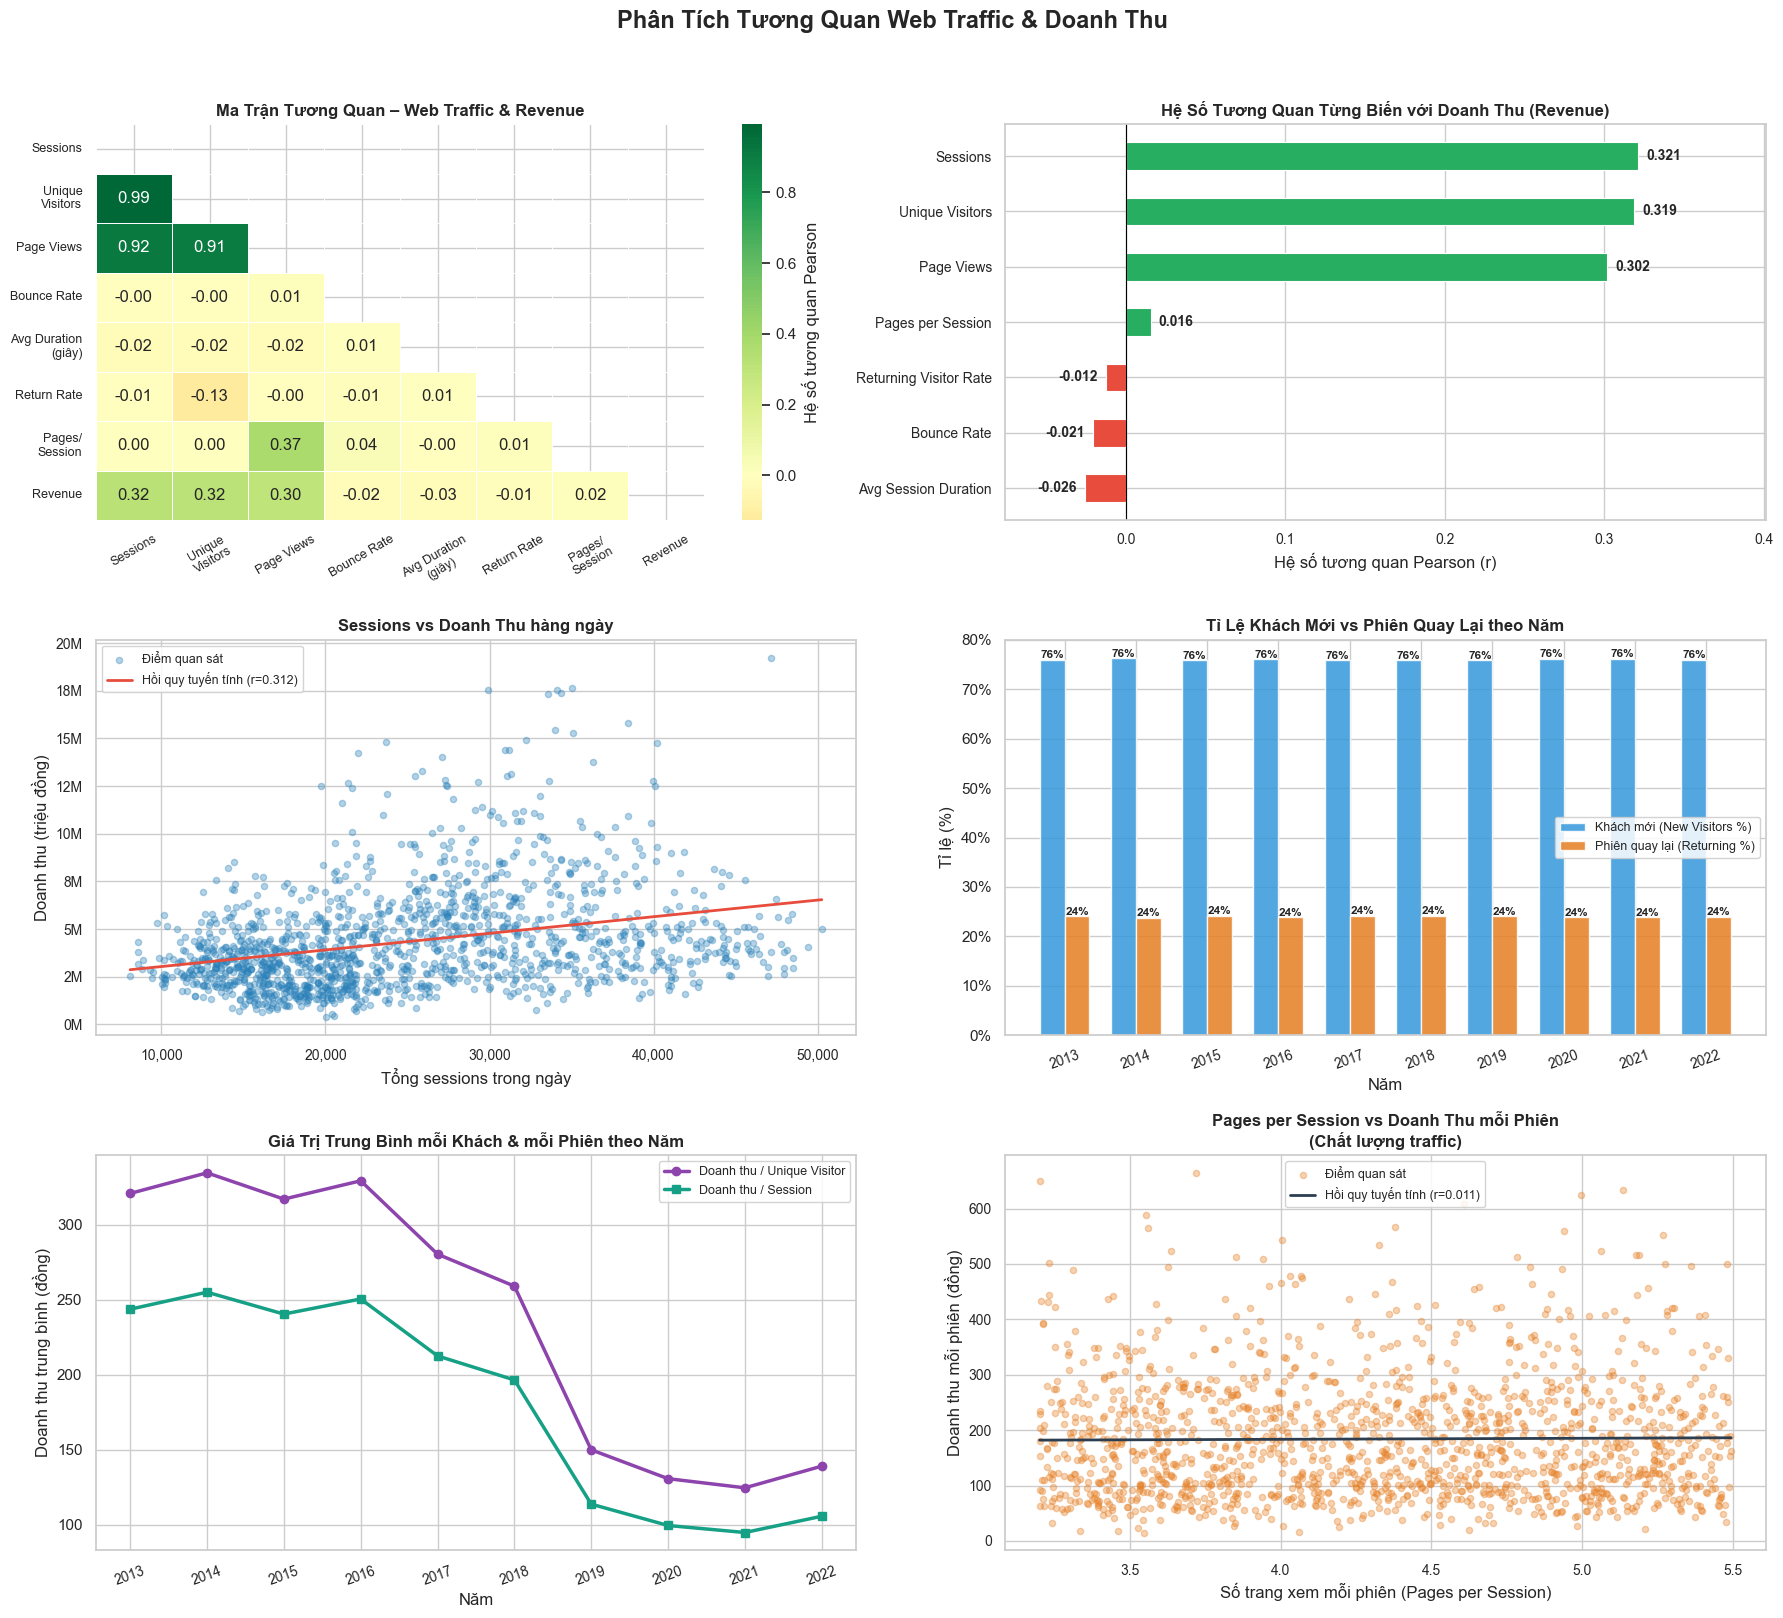

Đã lưu: web_traffic_correlation.png

=== TƯƠNG QUAN VỚI REVENUE ===
Avg Session Duration     -0.025622
Bounce Rate              -0.020551
Returning Visitor Rate   -0.012382
Pages per Session         0.015666
Page Views                0.301573
Unique Visitors           0.318787
Sessions                  0.321050

Doanh thu TB/Unique Visitor: 241 đồng
Doanh thu TB/Session:        183 đồng
Pages per Session TB:        4.3 trang
Returning Visitor Rate TB:   24.0%


In [12]:
"""
WEB TRAFFIC CORRELATION & VISITOR ANALYSIS
- Tương quan các biến web_traffic với doanh thu (revenue)
- Phân tích unique_visitors & sessions: new vs returning, loyalty, traffic quality
"""
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

matplotlib.rcParams['font.family']     = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Tahoma', 'Segoe UI', 'DejaVu Sans']

# ── Load & join data ──────────────────────────────────────────────────────────
web   = pd.read_csv('../data/raw/web_traffic.csv')
orders = pd.read_csv('../data/raw/orders.csv', low_memory=False)
items  = pd.read_csv('../data/raw/order_items.csv')

items['revenue'] = items['quantity'] * items['unit_price']
daily_rev = (
    orders.merge(items[['order_id', 'revenue']], on='order_id')
    .groupby('order_date')['revenue'].sum()
    .reset_index()
    .rename(columns={'order_date': 'date'})
)

web_daily = (
    web.groupby('date').agg(
        sessions                 = ('sessions',                'sum'),
        unique_visitors          = ('unique_visitors',         'sum'),
        page_views               = ('page_views',             'sum'),
        bounce_rate              = ('bounce_rate',             'mean'),
        avg_session_duration_sec = ('avg_session_duration_sec','mean')
    ).reset_index()
)

df = web_daily.merge(daily_rev, on='date', how='inner')
df['date'] = pd.to_datetime(df['date'])
df['Năm']  = df['date'].dt.year

# ── Các chỉ số từ unique_visitors & sessions ──────────────────────────────────
# Tỉ lệ quay lại = phiên thừa / tổng phiên (sessions > unique_visitors → có người quay lại)
df['returning_sessions']   = df['sessions'] - df['unique_visitors']
df['return_rate']          = df['returning_sessions'] / df['sessions']          # Returning Visitor Rate
df['pages_per_session']    = df['page_views'] / df['sessions']                  # Trang/phiên
df['revenue_per_session']  = df['revenue'] / df['sessions']                     # Doanh thu/phiên
df['revenue_per_visitor']  = df['revenue'] / df['unique_visitors']              # Doanh thu/khách duy nhất

# ── Tương quan ────────────────────────────────────────────────────────────────
corr_cols = ['sessions', 'unique_visitors', 'page_views',
             'bounce_rate', 'avg_session_duration_sec',
             'return_rate', 'pages_per_session', 'revenue']
corr_matrix = df[corr_cols].corr()

# ── Figure: 3×2 = 6 subplots ─────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle('Phân Tích Tương Quan Web Traffic & Doanh Thu',
             fontsize=17, fontweight='bold', y=1.01)

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 1 (hàng 1, trái): Heatmap tương quan đầy đủ
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
labels = ['Sessions', 'Unique\nVisitors', 'Page Views',
          'Bounce Rate', 'Avg Duration\n(giây)', 'Return Rate',
          'Pages/\nSession', 'Revenue']
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # chỉ hiện tam giác dưới
sns.heatmap(corr_matrix, ax=ax1, mask=mask,
            annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Hệ số tương quan Pearson'})
ax1.set_title('Ma Trận Tương Quan – Web Traffic & Revenue', fontweight='bold', fontsize=12)
ax1.tick_params(axis='x', rotation=30, labelsize=9)
ax1.tick_params(axis='y', rotation=0,  labelsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 2 (hàng 1, phải): Tương quan từng biến với Revenue (Bar chart)
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]
corr_with_rev = (
    corr_matrix['revenue']
    .drop('revenue')
    .sort_values()
    .rename(index={
        'sessions': 'Sessions',
        'unique_visitors': 'Unique Visitors',
        'page_views': 'Page Views',
        'bounce_rate': 'Bounce Rate',
        'avg_session_duration_sec': 'Avg Session Duration',
        'return_rate': 'Returning Visitor Rate',
        'pages_per_session': 'Pages per Session'
    })
)
colors2 = ['#27AE60' if v > 0 else '#E74C3C' for v in corr_with_rev]
bars2   = ax2.barh(corr_with_rev.index, corr_with_rev.values,
                   color=colors2, edgecolor='white', linewidth=0.8, height=0.5)
ax2.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars2, corr_with_rev.values):
    ha = 'left' if val >= 0 else 'right'
    offset = 0.005 if val >= 0 else -0.005
    ax2.text(val + offset, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', ha=ha, fontsize=10, fontweight='bold')
ax2.set_title('Hệ Số Tương Quan Từng Biến với Doanh Thu (Revenue)',
              fontweight='bold', fontsize=12)
ax2.set_xlabel('Hệ số tương quan Pearson (r)')
ax2.set_xlim(corr_with_rev.min() - 0.05, corr_with_rev.max() + 0.08)
ax2.tick_params(labelsize=10)

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 3 (hàng 2, trái): Scatter Sessions vs Revenue + đường hồi quy
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]
sample = df.sample(n=min(1500, len(df)), random_state=42)
slope, intercept, r, p, _ = stats.linregress(sample['sessions'], sample['revenue'])
x_line = np.linspace(sample['sessions'].min(), sample['sessions'].max(), 100)
ax3.scatter(sample['sessions'], sample['revenue'] / 1e6,
            alpha=0.35, s=20, color='#2980B9', label='Điểm quan sát')
ax3.plot(x_line, (slope * x_line + intercept) / 1e6,
         color='#E74C3C', linewidth=2, label=f'Hồi quy tuyến tính (r={r:.3f})')
ax3.set_title('Sessions vs Doanh Thu hàng ngày', fontweight='bold', fontsize=12)
ax3.set_xlabel('Tổng sessions trong ngày')
ax3.set_ylabel('Doanh thu (triệu đồng)')
ax3.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}M'))
ax3.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax3.legend(fontsize=9, framealpha=0.85)
ax3.tick_params(labelsize=10)

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 4 (hàng 2, phải): New vs Returning Visitors theo năm
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]
yearly = df.groupby('Năm').agg(
    unique_visitors   = ('unique_visitors',   'sum'),
    returning_sessions= ('returning_sessions','sum'),
    sessions          = ('sessions',           'sum')
).reset_index()
yearly['new_pct']       = yearly['unique_visitors']    / yearly['sessions'] * 100
yearly['returning_pct'] = yearly['returning_sessions'] / yearly['sessions'] * 100

x4 = np.arange(len(yearly))
w  = 0.35
ax4.bar(x4 - w/2, yearly['new_pct'],       w,
        label='Khách mới (New Visitors %)',      color='#3498DB', alpha=0.85)
ax4.bar(x4 + w/2, yearly['returning_pct'], w,
        label='Phiên quay lại (Returning %)', color='#E67E22', alpha=0.85)
for xi, (n, r) in zip(x4, zip(yearly['new_pct'], yearly['returning_pct'])):
    ax4.text(xi - w/2, n + 0.3, f'{n:.0f}%', ha='center', fontsize=8.5, fontweight='bold')
    ax4.text(xi + w/2, r + 0.3, f'{r:.0f}%', ha='center', fontsize=8.5, fontweight='bold')
ax4.set_title('Tỉ Lệ Khách Mới vs Phiên Quay Lại theo Năm',
              fontweight='bold', fontsize=12)
ax4.set_xlabel('Năm')
ax4.set_ylabel('Tỉ lệ (%)')
ax4.set_xticks(x4)
ax4.set_xticklabels(yearly['Năm'], rotation=20, fontsize=10)
ax4.legend(fontsize=9, framealpha=0.85)
ax4.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 5 (hàng 3, trái): Doanh thu/Khách duy nhất theo năm (Revenue per Visitor)
# ─────────────────────────────────────────────────────────────────────────────
ax5 = axes[2, 0]
yearly_rpv = df.groupby('Năm').agg(
    revenue          = ('revenue',          'sum'),
    unique_visitors  = ('unique_visitors',  'sum'),
    sessions         = ('sessions',         'sum')
).reset_index()
yearly_rpv['revenue_per_visitor'] = yearly_rpv['revenue'] / yearly_rpv['unique_visitors']
yearly_rpv['revenue_per_session'] = yearly_rpv['revenue'] / yearly_rpv['sessions']

ax5.plot(yearly_rpv['Năm'].astype(str), yearly_rpv['revenue_per_visitor'],
         marker='o', linewidth=2.5, color='#8E44AD', markersize=6,
         label='Doanh thu / Unique Visitor')
ax5.plot(yearly_rpv['Năm'].astype(str), yearly_rpv['revenue_per_session'],
         marker='s', linewidth=2.5, color='#16A085', markersize=6,
         label='Doanh thu / Session')
ax5.set_title('Giá Trị Trung Bình mỗi Khách & mỗi Phiên theo Năm',
              fontweight='bold', fontsize=12)
ax5.set_xlabel('Năm')
ax5.set_ylabel('Doanh thu trung bình (đồng)')
ax5.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax5.tick_params(axis='x', rotation=20, labelsize=10)
ax5.legend(fontsize=9, framealpha=0.85)

# ─────────────────────────────────────────────────────────────────────────────
# Subplot 6 (hàng 3, phải): Pages per Session vs Revenue per Session (Scatter)
# ─────────────────────────────────────────────────────────────────────────────
ax6 = axes[2, 1]
sample2 = df.sample(n=min(1500, len(df)), random_state=7)
slope6, intercept6, r6, p6, _ = stats.linregress(
    sample2['pages_per_session'], sample2['revenue_per_session']
)
x6_line = np.linspace(sample2['pages_per_session'].min(),
                      sample2['pages_per_session'].max(), 100)
ax6.scatter(sample2['pages_per_session'], sample2['revenue_per_session'],
            alpha=0.35, s=20, color='#E67E22', label='Điểm quan sát')
ax6.plot(x6_line, slope6 * x6_line + intercept6,
         color='#2C3E50', linewidth=2, label=f'Hồi quy tuyến tính (r={r6:.3f})')
ax6.set_title('Pages per Session vs Doanh Thu mỗi Phiên\n(Chất lượng traffic)',
              fontweight='bold', fontsize=12)
ax6.set_xlabel('Số trang xem mỗi phiên (Pages per Session)')
ax6.set_ylabel('Doanh thu mỗi phiên (đồng)')
ax6.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax6.legend(fontsize=9, framealpha=0.85)
ax6.tick_params(labelsize=10)

# ── Lưu & hiển thị ───────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('./web_traffic_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: web_traffic_correlation.png")

# ── In tóm tắt ───────────────────────────────────────────────────────────────
print("\n=== TƯƠNG QUAN VỚI REVENUE ===")
print(corr_with_rev.to_string())
print(f"\nDoanh thu TB/Unique Visitor: {df['revenue_per_visitor'].mean():,.0f} đồng")
print(f"Doanh thu TB/Session:        {df['revenue_per_session'].mean():,.0f} đồng")
print(f"Pages per Session TB:        {df['pages_per_session'].mean():.1f} trang")
print(f"Returning Visitor Rate TB:   {df['return_rate'].mean()*100:.1f}%")


## Insights – Tương Quan Web Traffic & Doanh Thu

---

**1. Sessions, Unique Visitors, Page Views – 3 biến này gần như một**

Ba biến có tương quan với nhau cực cao (r = 0.91–0.99), nghĩa là
chúng **đo cùng một thứ**: quy mô traffic. Khi dùng để phân tích,
chỉ cần chọn **một biến đại diện** (sessions) là đủ, tránh đa cộng tuyến.

---

**2. Traffic tăng → Doanh thu tăng, nhưng mối quan hệ còn yếu (r ≈ 0.32)**

Sessions, Unique Visitors, Page Views đều tương quan dương với revenue
nhưng hệ số chỉ ở mức **trung bình (~0.30–0.32)**. Điều này cho thấy
**tăng traffic chưa đủ** – cần cải thiện chất lượng chuyển đổi song song.

---

**3. Bounce Rate, Thời gian phiên, Return Rate – không ảnh hưởng đến doanh thu**

Cả ba biến có r ≈ 0 (–0.01 đến –0.03), tức là **không có tương quan
tuyến tính với doanh thu**. Cải thiện các chỉ số này không tự động
tăng doanh thu nếu không có chiến lược chuyển đổi rõ ràng.

---

**4. Tỉ lệ khách mới/quay lại hoàn toàn bất động suốt 10 năm**

Mỗi năm đều duy trì **~76% khách mới – 24% phiên quay lại**, không thay đổi
từ 2013 đến 2022. Website **chưa có chiến lược giữ chân khách hàng** hiệu quả
(loyalty program, retargeting, push notification).

---

**5. Doanh thu mỗi khách giảm mạnh – báo hiệu suy giảm chất lượng traffic**

Revenue/Unique Visitor giảm từ ~**320 đồng (2013)** xuống còn ~**140 đồng (2022)**,
tức mất hơn **55% giá trị** trong 10 năm. Traffic tăng về số lượng nhưng
**chất lượng khách hàng ngày càng thấp hơn**.

---

**6. Số trang xem/phiên không dự đoán được doanh thu (r ≈ 0.011)**

Khách xem nhiều hay ít trang cũng không ảnh hưởng đến doanh thu mỗi phiên.
Vấn đề không phải ở **lượng nội dung xem**, mà là **nội dung đúng sản phẩm**
dẫn đến quyết định mua hàng.
```

## Insight Tổng

> Website **thu hút được traffic** nhưng **không chuyển đổi được thành doanh thu**.

- Traffic tăng → doanh thu tăng yếu (r = 0.32)
- ~99% khách vào mà **không mua**
- Doanh thu/khách giảm **55% trong 10 năm**
- Tỉ lệ khách quay lại **bất động** suốt 10 năm (24%)

**→ Ưu tiên tối ưu chuyển đổi và giữ chân khách hàng, không phải tăng traffic.**


---
---
# PHẦN MỞ RỘNG – Cross-Table Insights
> Phân tích kết hợp `web_traffic` × `promotions` × `inventory` × `sales`


## Khuyến Mãi Có Thực Sự Kéo Traffic Và Chuyển Đổi Không?

**Câu hỏi kinh doanh:** Trong những ngày đang có khuyến mãi, website có nhiều sessions hơn, bounce rate thấp hơn và doanh thu cao hơn không?

**Dữ liệu:** `promotions.csv` + `web_traffic.csv` + `sales.csv`

**Phương pháp:**
- Tạo cột flag `has_promo` = 1 nếu ngày đó có ít nhất 1 promotion đang active
- So sánh phân phối sessions, bounce_rate, revenue giữa ngày promo vs. ngày thường
- Visualize bằng violin plot + bar chart


In [ ]:
#!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


               sessions          bounce_rate            Revenue             revenue_per_session        
                   mean   median        mean median        mean      median                mean  median
promo_label                                                                                            
Ngày có Promo  24606.06  23068.0         0.0    0.0  3990789.21  3428606.64              172.97  152.40
Ngày thường    25424.16  24284.0         0.0    0.0  4563856.89  3836294.44              191.29  176.07


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11728\4197841543.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_11728\4197841543.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


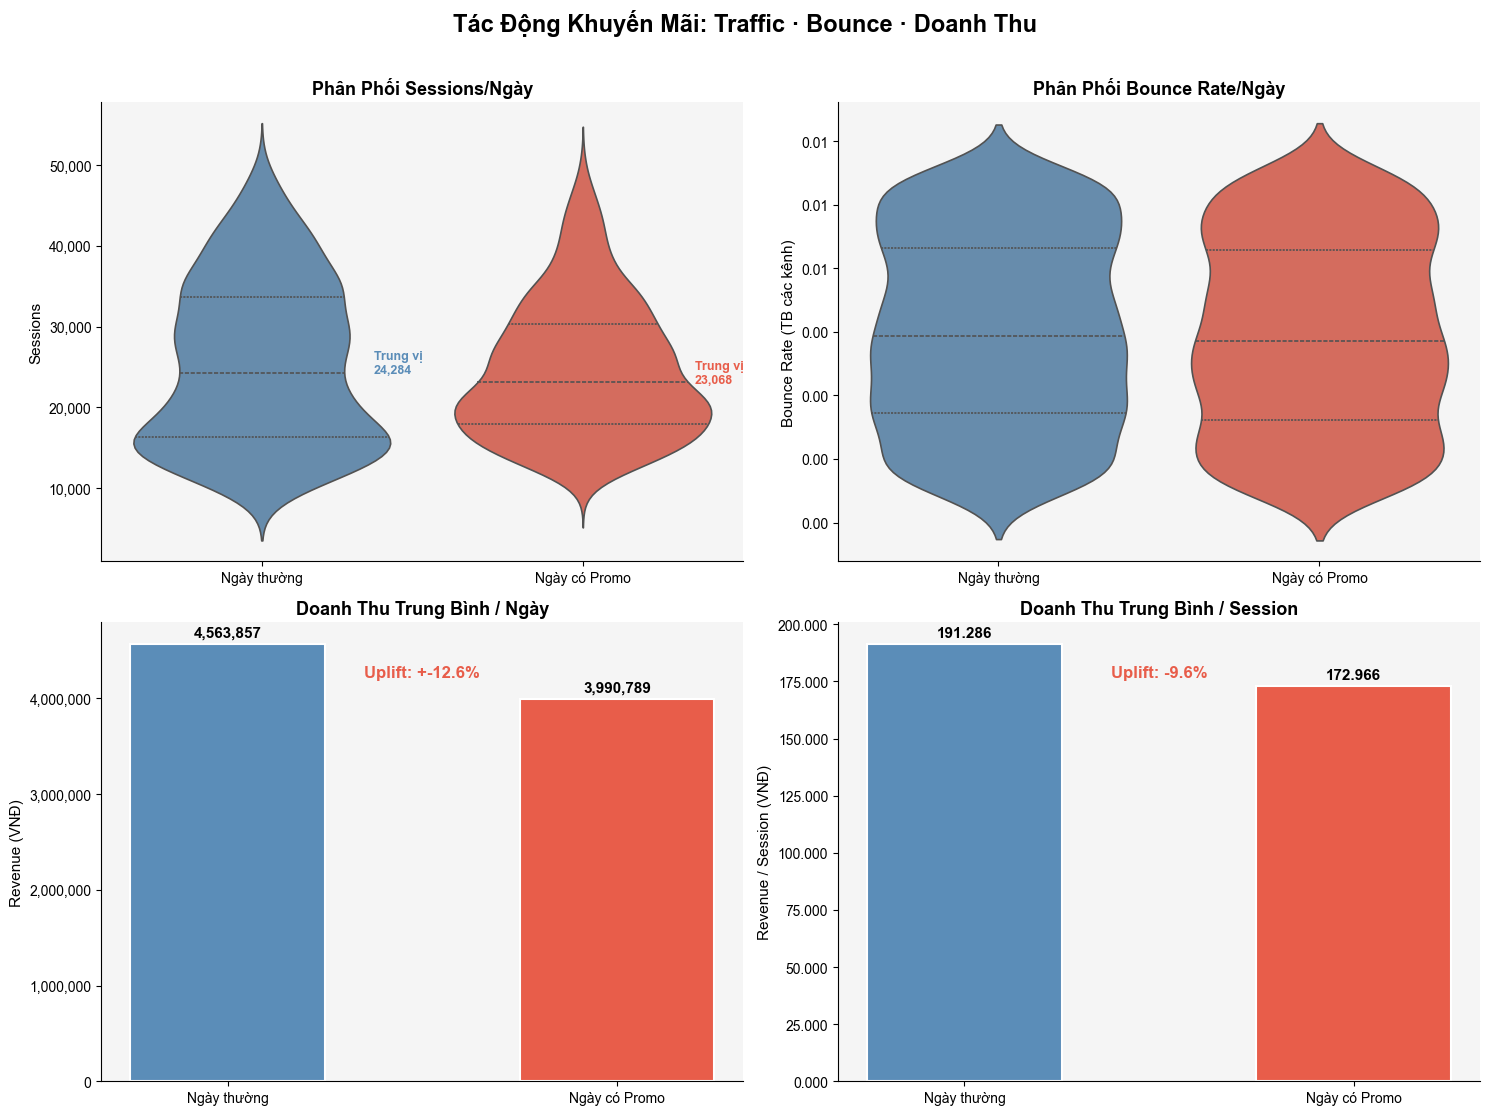


Số ngày có promo: 1707 / Tổng: 3652


In [ ]:
"""
PROMOTION × WEB TRAFFIC × REVENUE ANALYSIS
Đánh giá tác động của khuyến mãi lên lưu lượng và chuyển đổi.
"""
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

matplotlib.rcParams["font.family"]     = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial", "Tahoma", "Segoe UI", "DejaVu Sans"]

# ── Load data ────────────────────────────────────────────────────────────
promo   = pd.read_csv("../data/raw/promotions.csv")
web     = pd.read_csv("../data/raw/web_traffic.csv")
sales   = pd.read_csv("../data/raw/sales.csv")

promo["start_date"] = pd.to_datetime(promo["start_date"])
promo["end_date"]   = pd.to_datetime(promo["end_date"])
web["date"]         = pd.to_datetime(web["date"])
sales["Date"]       = pd.to_datetime(sales["Date"])

# ── Tạo tập ngày có promo active ─────────────────────────────────────────
# Expand mỗi promo thành danh sách ngày
promo_days = set()
for _, row in promo.iterrows():
    days = pd.date_range(row["start_date"], row["end_date"])
    promo_days.update(days)

# Gộp web traffic theo ngày (sum sessions; mean bounce_rate & duration)
web_daily = web.groupby("date").agg(
    sessions            = ("sessions", "sum"),
    unique_visitors     = ("unique_visitors", "sum"),
    bounce_rate         = ("bounce_rate", "mean"),
    avg_duration        = ("avg_session_duration_sec", "mean"),
).reset_index()

web_daily["has_promo"] = web_daily["date"].isin(promo_days).astype(int)

# Merge với sales
combined = web_daily.merge(sales, left_on="date", right_on="Date", how="inner")
combined["revenue_per_session"] = combined["Revenue"] / combined["sessions"].replace(0, np.nan)

label_map = {0: "Ngày thường", 1: "Ngày có Promo"}
combined["promo_label"] = combined["has_promo"].map(label_map)

# ── Thống kê tóm tắt ─────────────────────────────────────────────────────
summary = combined.groupby("promo_label")[[
    "sessions", "bounce_rate", "Revenue", "revenue_per_session"
]].agg(["mean", "median"]).round(2)
print(summary.to_string())

# ── Palette & helpers ────────────────────────────────────────────────────
PAL    = {"Ngày thường": "#5B8DB8", "Ngày có Promo": "#E85D4A"}
GREY   = "#f5f5f5"

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Tác Động Khuyến Mãi: Traffic · Bounce · Doanh Thu",
    fontsize=17, fontweight="bold", y=1.01
)

# --- Plot 1: Sessions violin ------------------------------------------------
ax = axes[0, 0]
order = ["Ngày thường", "Ngày có Promo"]
sns.violinplot(
    data=combined, x="promo_label", y="sessions",
    order=order, palette=PAL, inner="quartile",
    linewidth=1.2, ax=ax
)
ax.set_title("Phân Phối Sessions/Ngày", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Sessions", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for label in order:
    med = combined.loc[combined["promo_label"] == label, "sessions"].median()
    ax.annotate(f"Trung vị\n{med:,.0f}", xy=(order.index(label), med),
                xytext=(order.index(label) + 0.35, med),
                fontsize=9, color=PAL[label], fontweight="bold")

# --- Plot 2: Bounce Rate violin ------------------------------------------
ax = axes[0, 1]
sns.violinplot(
    data=combined, x="promo_label", y="bounce_rate",
    order=order, palette=PAL, inner="quartile",
    linewidth=1.2, ax=ax
)
ax.set_title("Phân Phối Bounce Rate/Ngày", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Bounce Rate (TB các kênh)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}"))

# --- Plot 3: Revenue bar ---------------------------------------------------
ax = axes[1, 0]
rev_mean = combined.groupby("promo_label")["Revenue"].mean().reindex(order)
bars = ax.bar(order, rev_mean.values,
              color=[PAL[l] for l in order], width=0.5,
              edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, rev_mean.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + rev_mean.max()*0.01,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Doanh Thu Trung Bình / Ngày", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (VNĐ)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlabel("")
uplift_pct = (rev_mean["Ngày có Promo"] / rev_mean["Ngày thường"] - 1) * 100
ax.annotate(f"Uplift: +{uplift_pct:.1f}%",
            xy=(0.5, 0.88), xycoords="axes fraction",
            ha="center", fontsize=12, color="#E85D4A", fontweight="bold")

# --- Plot 4: Revenue/Session bar -----------------------------------------
ax = axes[1, 1]
rps_mean = combined.groupby("promo_label")["revenue_per_session"].mean().reindex(order)
bars = ax.bar(order, rps_mean.values,
              color=[PAL[l] for l in order], width=0.5,
              edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, rps_mean.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + rps_mean.max()*0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Doanh Thu Trung Bình / Session", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue / Session (VNĐ)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.3f}"))
ax.set_xlabel("")
uplift_rps = (rps_mean["Ngày có Promo"] / rps_mean["Ngày thường"] - 1) * 100
ax.annotate(f"Uplift: {uplift_rps:+.1f}%",
            xy=(0.5, 0.88), xycoords="axes fraction",
            ha="center", fontsize=12, color="#E85D4A", fontweight="bold")

for ax in axes.flat:
    ax.set_facecolor(GREY)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()
print("\nSố ngày có promo:", sum(combined["has_promo"]), "/ Tổng:", len(combined))


## Loại Khuyến Mãi Nào Hiệu Quả Nhất? (promo_type × Revenue)

**Câu hỏi:** `percentage` discount hay `fixed` discount mang lại doanh thu/session cao hơn?

**Phương pháp:** Join ngày active của từng `promo_type` với `sales` + `web_traffic`,
sau đó so sánh revenue per session và % số ngày active theo loại.


promo_type  n_days  avg_revenue  avg_rps  avg_bounce  avg_sessions
     fixed     175  3569010.517  128.611       0.004     30223.440
percentage    1552  4055615.973  178.487       0.004     24005.606


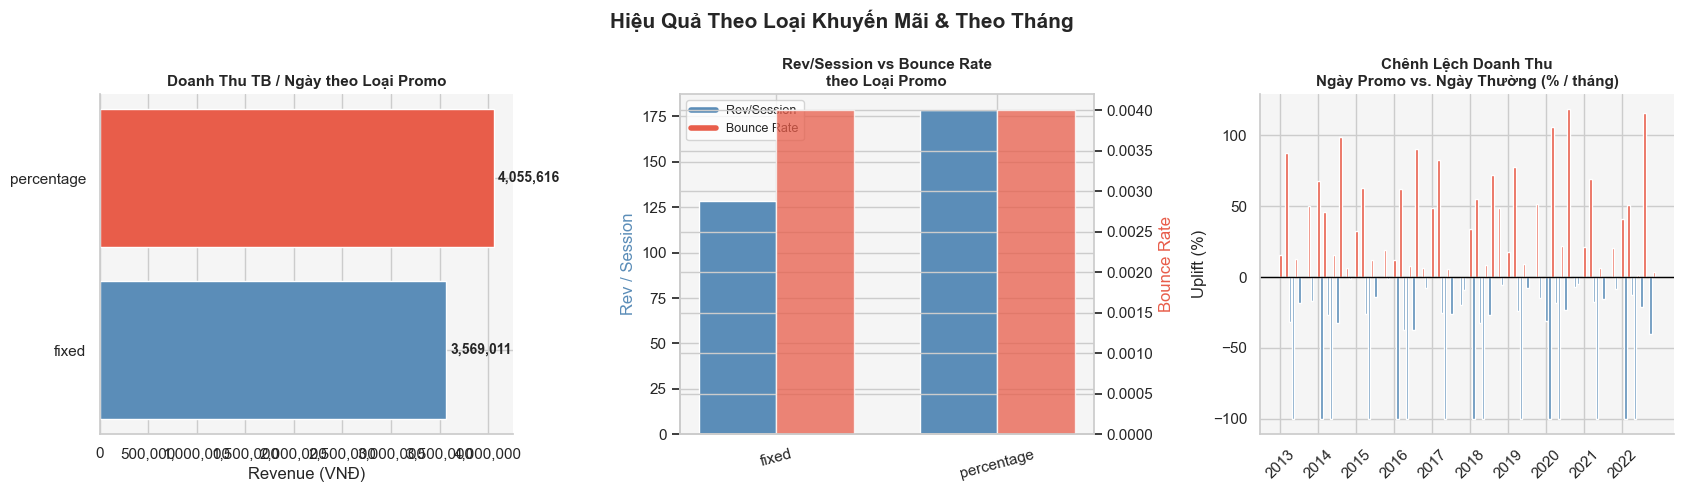

In [ ]:
"""
PROMO TYPE EFFECTIVENESS – percentage vs fixed
"""

# Đánh dấu ngày thuộc promo_type nào (ưu tiên: nếu ngày có cả 2 thì giữ cả 2 dòng)
rows = []
for _, row in promo.iterrows():
    for d in pd.date_range(row["start_date"], row["end_date"]):
        rows.append({"date": d, "promo_type": row["promo_type"],
                     "promo_channel": row.get("promo_channel", "all")})

promo_daily = pd.DataFrame(rows).drop_duplicates(subset=["date","promo_type"])

# Merge với web_daily + sales
pt_df = promo_daily.merge(web_daily[["date","sessions","bounce_rate"]],
                          on="date", how="inner")
pt_df = pt_df.merge(sales[["Date","Revenue"]], left_on="date",
                    right_on="Date", how="inner")
pt_df["rev_per_session"] = pt_df["Revenue"] / pt_df["sessions"].replace(0, np.nan)

# Aggregate theo promo_type
pt_agg = pt_df.groupby("promo_type").agg(
    n_days          = ("date", "nunique"),
    avg_revenue     = ("Revenue", "mean"),
    avg_rps         = ("rev_per_session", "mean"),
    avg_bounce      = ("bounce_rate", "mean"),
    avg_sessions    = ("sessions", "mean"),
).round(3).reset_index()
print(pt_agg.to_string(index=False))

# ── Monthly revenue uplift: promo ngày vs. non-promo cùng tháng ─────────
combined["month_year"] = combined["date"].dt.to_period("M")
monthly = combined.groupby(["month_year","has_promo"])["Revenue"].mean().unstack(fill_value=0)
monthly.columns = ["Ngày thường", "Ngày có Promo"]
monthly["uplift_abs"] = monthly["Ngày có Promo"] - monthly["Ngày thường"]
monthly["uplift_pct"] = (monthly["uplift_abs"] / monthly["Ngày thường"].replace(0,np.nan)*100).round(1)
monthly.index = monthly.index.to_timestamp()

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor("white")
fig.suptitle("Hiệu Quả Theo Loại Khuyến Mãi & Theo Tháng",
             fontsize=15, fontweight="bold")

COLORS = ["#5B8DB8","#E85D4A","#6CC788","#F5A623"]

# Plot A: Avg Revenue per day by promo_type
ax = axes[0]
bars = ax.barh(pt_agg["promo_type"], pt_agg["avg_revenue"],
               color=COLORS[:len(pt_agg)], edgecolor="white")
for bar, val in zip(bars, pt_agg["avg_revenue"]):
    ax.text(val + pt_agg["avg_revenue"].max()*0.01, bar.get_y()+bar.get_height()/2,
            f"{val:,.0f}", va="center", fontsize=10, fontweight="bold")
ax.set_title("Doanh Thu TB / Ngày theo Loại Promo", fontsize=11, fontweight="bold")
ax.set_xlabel("Revenue (VNĐ)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

# Plot B: Rev/Session + Bounce Rate by promo_type (dual bar)
ax = axes[1]
x = np.arange(len(pt_agg))
w = 0.35
b1 = ax.bar(x - w/2, pt_agg["avg_rps"], w, label="Rev/Session", color="#5B8DB8")
ax2b = ax.twinx()
b2 = ax2b.bar(x + w/2, pt_agg["avg_bounce"], w, label="Bounce Rate TB", color="#E85D4A", alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels(pt_agg["promo_type"], rotation=15)
ax.set_ylabel("Rev / Session", color="#5B8DB8")
ax2b.set_ylabel("Bounce Rate", color="#E85D4A")
ax.set_title("Rev/Session vs Bounce Rate\ntheo Loại Promo", fontsize=11, fontweight="bold")
lines = [plt.Line2D([0],[0],color="#5B8DB8",lw=4),
         plt.Line2D([0],[0],color="#E85D4A",lw=4)]
ax.legend(lines, ["Rev/Session","Bounce Rate"], fontsize=9)

# Plot C: Monthly Revenue uplift %
ax = axes[2]
colors_up = ["#E85D4A" if v > 0 else "#5B8DB8" for v in monthly["uplift_pct"]]
ax.bar(range(len(monthly)), monthly["uplift_pct"], color=colors_up, width=0.8)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(range(0, len(monthly), 12))
ax.set_xticklabels(
    [str(monthly.index[i].year) for i in range(0, len(monthly), 12)],
    rotation=45
)
ax.set_title("Chênh Lệch Doanh Thu\nNgày Promo vs. Ngày Thường (% / tháng)",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Uplift (%)")

for ax in axes:
    ax.set_facecolor("#f5f5f5")
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()


---
## Hết Hàng Ảnh Hưởng Thế Nào Đến Website Và Doanh Thu?

**Giả thuyết:** Khi nhiều sản phẩm bị stockout (hết hàng), khách vào web không tìm được
hàng → bounce rate tăng, revenue per session giảm.

**Dữ liệu:** `inventory.csv` (snapshot cuối tháng) + `web_traffic.csv` + `sales.csv`

**Phương pháp:**
1. Tính `stockout_ratio` = tỷ lệ sản phẩm có `stockout_flag=1` mỗi tháng
2. Resample web_traffic lên tháng
3. Scatter plot + correlation: stockout_ratio vs. bounce_rate / revenue_per_session



=== Correlation Matrix (monthly) ===
                 stockout_ratio  overstock_ratio  fill_rate_avg  bounce_rate  rev_per_session  Revenue  sell_through
stockout_ratio            1.000           -0.263         -0.569       -0.032            0.180    0.204         0.283
overstock_ratio          -0.263            1.000          0.559        0.051           -0.292   -0.637        -0.930
fill_rate_avg            -0.569            0.559          1.000        0.123           -0.427   -0.488        -0.648
bounce_rate              -0.032            0.051          0.123        1.000           -0.110   -0.101        -0.110
rev_per_session           0.180           -0.292         -0.427       -0.110            1.000    0.589         0.559
Revenue                   0.204           -0.637         -0.488       -0.101            0.589    1.000         0.741
sell_through              0.283           -0.930         -0.648       -0.110            0.559    0.741         1.000


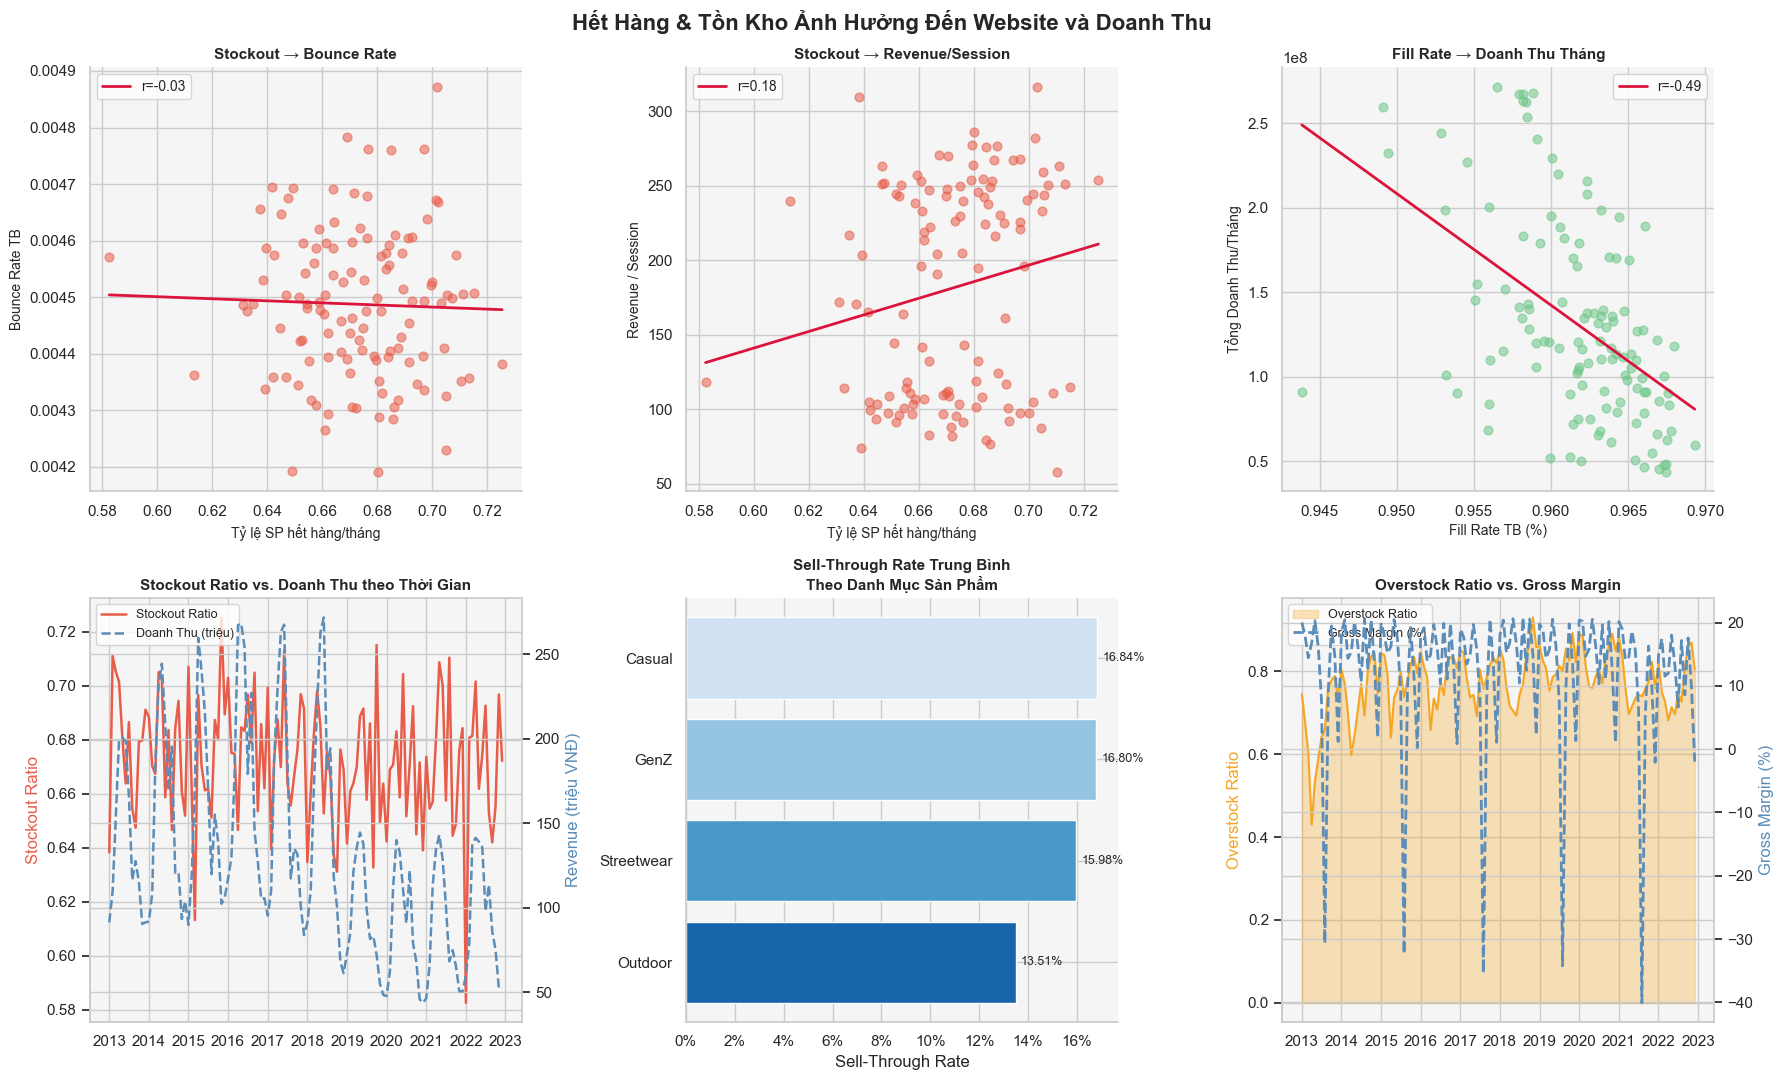

In [ ]:
"""
INVENTORY STOCKOUT × WEB TRAFFIC × REVENUE
"""
inv  = pd.read_csv("../../data/raw/inventory.csv")
inv["snapshot_date"] = pd.to_datetime(inv["snapshot_date"])
inv["month"]         = inv["snapshot_date"].dt.to_period("M")

# ── Tính stockout ratio và fill_rate TB theo tháng ──────────────────────
inv_month = inv.groupby("month").agg(
    stockout_ratio  = ("stockout_flag",  "mean"),
    overstock_ratio = ("overstock_flag", "mean"),
    fill_rate_avg   = ("fill_rate",      "mean"),
    sell_through    = ("sell_through_rate", "mean"),
).reset_index()

# ── Web traffic theo tháng ──────────────────────────────────────────────
web["month"] = web["date"].dt.to_period("M")
web_month = web.groupby("month").agg(
    sessions        = ("sessions", "sum"),
    unique_visitors = ("unique_visitors", "sum"),
    bounce_rate     = ("bounce_rate", "mean"),
    avg_duration    = ("avg_session_duration_sec", "mean"),
).reset_index()

# ── Sales theo tháng ────────────────────────────────────────────────────
sales["month"] = sales["Date"].dt.to_period("M")
sales_month = sales.groupby("month").agg(
    Revenue = ("Revenue", "sum"),
    COGS    = ("COGS",    "sum"),
).reset_index()
sales_month["gross_margin"] = ((sales_month["Revenue"] - sales_month["COGS"])
                               / sales_month["Revenue"] * 100).round(2)

# ── Merge tất cả theo month ─────────────────────────────────────────────
monthly_all = (inv_month
    .merge(web_month,   on="month", how="inner")
    .merge(sales_month, on="month", how="inner")
)
monthly_all["rev_per_session"] = monthly_all["Revenue"] / monthly_all["sessions"]
monthly_all["ts"] = monthly_all["month"].dt.to_timestamp()

# ── Correlation table ───────────────────────────────────────────────────
corr_cols = ["stockout_ratio","overstock_ratio","fill_rate_avg",
             "bounce_rate","rev_per_session","Revenue","sell_through"]
print("\n=== Correlation Matrix (monthly) ===")
print(monthly_all[corr_cols].corr().round(3).to_string())

# ── Figures ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor("white")
fig.suptitle("Hết Hàng & Tồn Kho Ảnh Hưởng Đến Website và Doanh Thu",
             fontsize=16, fontweight="bold")

# Helper scatter
def scatter_with_reg(ax, x, y, data, xlabel, ylabel, title, color="#5B8DB8"):
    ax.scatter(data[x], data[y], alpha=0.55, color=color, s=40)
    m, b, r, p, _ = stats.linregress(data[x].dropna(), data[y].dropna())
    xr = np.linspace(data[x].min(), data[x].max(), 100)
    ax.plot(xr, m*xr+b, color="crimson", lw=2, label=f"r={r:.2f}")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_facecolor("#f5f5f5")
    ax.spines[["top","right"]].set_visible(False)

scatter_with_reg(axes[0,0], "stockout_ratio", "bounce_rate", monthly_all,
    "Tỷ lệ SP hết hàng/tháng", "Bounce Rate TB",
    "Stockout → Bounce Rate", "#E85D4A")

scatter_with_reg(axes[0,1], "stockout_ratio", "rev_per_session", monthly_all,
    "Tỷ lệ SP hết hàng/tháng", "Revenue / Session",
    "Stockout → Revenue/Session", "#E85D4A")

scatter_with_reg(axes[0,2], "fill_rate_avg", "Revenue", monthly_all,
    "Fill Rate TB (%)", "Tổng Doanh Thu/Tháng",
    "Fill Rate → Doanh Thu Tháng", "#6CC788")

# Time-series: Stockout ratio + Revenue (dual axis)
ax = axes[1,0]
ax2 = ax.twinx()
ax.plot(monthly_all["ts"], monthly_all["stockout_ratio"],
        color="#E85D4A", lw=1.8, label="Stockout Ratio")
ax2.plot(monthly_all["ts"], monthly_all["Revenue"]/1e6,
         color="#5B8DB8", lw=1.8, linestyle="--", label="Doanh Thu (triệu)")
ax.set_title("Stockout Ratio vs. Doanh Thu theo Thời Gian", fontsize=11, fontweight="bold")
ax.set_ylabel("Stockout Ratio", color="#E85D4A")
ax2.set_ylabel("Revenue (triệu VNĐ)", color="#5B8DB8")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=9, loc="upper left")
ax.set_facecolor("#f5f5f5")
ax.spines[["top","right"]].set_visible(False)

# Sell-through rate by category (top 5)
ax = axes[1,1]
st_cat = (inv.groupby("category")["sell_through_rate"]
            .mean().sort_values(ascending=True)
            .tail(8))
bars = ax.barh(st_cat.index, st_cat.values,
               color=sns.color_palette("Blues_r", len(st_cat)))
for bar, val in zip(bars, st_cat.values):
    ax.text(val + 0.002, bar.get_y()+bar.get_height()/2,
            f"{val:.2%}", va="center", fontsize=9)
ax.set_title("Sell-Through Rate Trung Bình\nTheo Danh Mục Sản Phẩm",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Sell-Through Rate")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0%}"))
ax.set_facecolor("#f5f5f5")
ax.spines[["top","right"]].set_visible(False)

# Overstock ratio time-series + gross margin
ax = axes[1,2]
ax2 = ax.twinx()
ax.fill_between(monthly_all["ts"], monthly_all["overstock_ratio"],
                alpha=0.3, color="#F5A623", label="Overstock Ratio")
ax.plot(monthly_all["ts"], monthly_all["overstock_ratio"],
        color="#F5A623", lw=1.5)
ax2.plot(monthly_all["ts"], monthly_all["gross_margin"],
         color="#5B8DB8", lw=2, linestyle="--", label="Gross Margin (%)")
ax.set_title("Overstock Ratio vs. Gross Margin", fontsize=11, fontweight="bold")
ax.set_ylabel("Overstock Ratio", color="#F5A623")
ax2.set_ylabel("Gross Margin (%)", color="#5B8DB8")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=9, loc="upper left")
ax.set_facecolor("#f5f5f5")
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()


---
## Khuyến Mãi Có Được Tung Ra Đúng Lúc Tồn Kho Tốt Không?

**Câu hỏi Prescriptive:** Nếu một chiến dịch khuyến mãi diễn ra khi tồn kho đang thấp
(fill_rate thấp, stockout cao), doanh thu sẽ không tăng như kỳ vọng — công ty 'đốt ngân sách'
vô ích. Phân tích này kiểm tra xem timing của promo có ăn khớp với sức khoẻ tồn kho không.

**Phương pháp:**  
- Mỗi tháng có promo → lấy fill_rate TB và stockout_ratio của tháng đó  
- Vẽ scatter: `fill_rate_avg` × `Revenue uplift` (promo so với average)  
- Phân loại: `Good timing` (fill_rate cao, uplift cao) vs. `Wasted budget` (fill_rate thấp, uplift thấp)



=== Phân Loại Tháng Promo Theo Inventory Health ===
quadrant
⚠️ Tiềm năng chưa khai thác\n(tồn kho tốt, doanh thu thấp)    35
🟡 May mắn\n(tồn kho yếu nhưng vẫn bán được)                   35
✅ Đúng lúc\n(tồn kho tốt, doanh thu cao)                      18
❌ Lãng phí\n(tồn kho yếu, doanh thu thấp)                     17


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22564\4094455327.py:83: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22564\4094455327.py:83: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22564\4094455327.py:83: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22564\4094455327.py:83: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22564\4094455327.py:83: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Ari

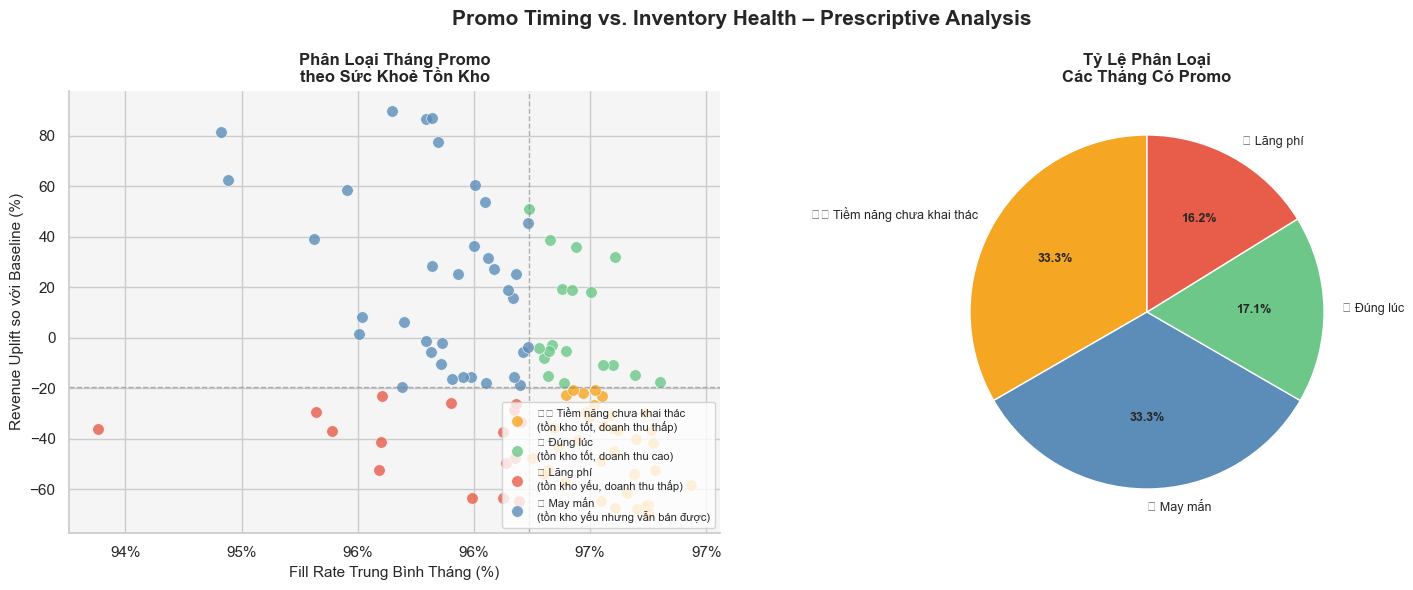

In [ ]:
"""
PROMO TIMING vs. INVENTORY HEALTH – Prescriptive Analysis
"""
# Tháng nào có promo?
promo_months = set()
for _, row in promo.iterrows():
    months = pd.period_range(row["start_date"], row["end_date"], freq="M")
    promo_months.update(months)

# Gán flag cho monthly_all
monthly_all["has_promo"] = monthly_all["month"].isin(promo_months).astype(int)

# Revenue baseline = median doanh thu tháng không có promo
baseline_rev = monthly_all.loc[monthly_all["has_promo"]==0, "Revenue"].median()
monthly_all["rev_uplift_pct"] = (monthly_all["Revenue"] / baseline_rev - 1) * 100

# Chỉ xét tháng có promo
promo_timing = monthly_all[monthly_all["has_promo"]==1].copy()

# Quadrant classification
fr_med  = promo_timing["fill_rate_avg"].median()
rup_med = promo_timing["rev_uplift_pct"].median()

def quadrant(row):
    if row["fill_rate_avg"] >= fr_med and row["rev_uplift_pct"] >= rup_med:
        return "✅ Đúng lúc\n(tồn kho tốt, doanh thu cao)"
    elif row["fill_rate_avg"] >= fr_med and row["rev_uplift_pct"] < rup_med:
        return "⚠️ Tiềm năng chưa khai thác\n(tồn kho tốt, doanh thu thấp)"
    elif row["fill_rate_avg"] < fr_med and row["rev_uplift_pct"] >= rup_med:
        return "🟡 May mắn\n(tồn kho yếu nhưng vẫn bán được)"
    else:
        return "❌ Lãng phí\n(tồn kho yếu, doanh thu thấp)"

promo_timing["quadrant"] = promo_timing.apply(quadrant, axis=1)

q_count = promo_timing["quadrant"].value_counts()
print("\n=== Phân Loại Tháng Promo Theo Inventory Health ===")
print(q_count.to_string())

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("white")
fig.suptitle("Promo Timing vs. Inventory Health – Prescriptive Analysis",
             fontsize=15, fontweight="bold")

Q_COLORS = {
    "✅ Đúng lúc\n(tồn kho tốt, doanh thu cao)":          "#6CC788",
    "⚠️ Tiềm năng chưa khai thác\n(tồn kho tốt, doanh thu thấp)": "#F5A623",
    "🟡 May mắn\n(tồn kho yếu nhưng vẫn bán được)":       "#5B8DB8",
    "❌ Lãng phí\n(tồn kho yếu, doanh thu thấp)":         "#E85D4A",
}

# Plot A: Scatter quadrant
ax = axes[0]
for q, grp in promo_timing.groupby("quadrant"):
    ax.scatter(grp["fill_rate_avg"], grp["rev_uplift_pct"],
               label=q, color=Q_COLORS.get(q, "grey"),
               s=70, alpha=0.8, edgecolors="white", linewidth=0.5)
ax.axvline(fr_med,  color="grey", lw=1, linestyle="--", alpha=0.6)
ax.axhline(rup_med, color="grey", lw=1, linestyle="--", alpha=0.6)
ax.set_xlabel("Fill Rate Trung Bình Tháng (%)", fontsize=11)
ax.set_ylabel("Revenue Uplift so với Baseline (%)", fontsize=11)
ax.set_title("Phân Loại Tháng Promo\ntheo Sức Khoẻ Tồn Kho", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0%}"))
ax.set_facecolor("#f5f5f5")
ax.spines[["top","right"]].set_visible(False)

# Plot B: Pie chart of quadrant distribution
ax = axes[1]
labels_short = [q.split("\n")[0] for q in q_count.index]
colors_pie   = [Q_COLORS.get(q, "grey") for q in q_count.index]
wedges, texts, autotexts = ax.pie(
    q_count.values, labels=labels_short,
    colors=colors_pie, autopct="%1.1f%%",
    startangle=90, textprops={"fontsize": 9}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
ax.set_title("Tỷ Lệ Phân Loại\nCác Tháng Có Promo", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


---
## Kênh Promo Có Khớp Với Kênh Traffic Hiệu Quả Nhất Không?

**Câu hỏi:** `promo_channel` trong `promotions.csv` (email, social, etc.) có đang nhắm
đúng những kênh traffic mang lại revenue/session cao nhất không?

**Phương pháp:**
- Tính revenue/session và bounce rate theo `traffic_source`
- So sánh với phân phối `promo_channel` đang được đầu tư
- Vẽ bubble chart: trục X = revenue/session, trục Y = bounce_rate, size = % budget promo


In [ ]:
"""
CHANNEL ALIGNMENT: Promo Budget vs. Traffic Quality
"""
orders_df  = pd.read_csv("./data/raw/orders.csv")
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])

# Revenue per session và bounce rate theo traffic_source
web_src = web.groupby(["date","traffic_source"]).agg(
    sessions    = ("sessions", "sum"),
    bounce_rate = ("bounce_rate", "mean"),
).reset_index()

web_src_m = web.groupby("traffic_source").agg(
    total_sessions = ("sessions", "sum"),
    avg_bounce     = ("bounce_rate", "mean"),
    avg_duration   = ("avg_session_duration_sec", "mean"),
).reset_index()

# Đơn hàng theo order_source
orders_src = orders_df.groupby("order_source").agg(
    n_orders = ("order_id", "count"),
).reset_index().rename(columns={"order_source":"traffic_source"})

# Revenue tổng từ sales (dùng total, chia theo tỷ lệ đơn hàng)
total_rev   = sales["Revenue"].sum()
total_orders = orders_src["n_orders"].sum()
orders_src["est_revenue"] = orders_src["n_orders"] / total_orders * total_rev

src_combined = web_src_m.merge(orders_src, on="traffic_source", how="left")
src_combined["rev_per_session"] = src_combined["est_revenue"] / src_combined["total_sessions"]

# Promo channel distribution
promo_ch = (promo["promo_channel"].fillna("all")
            .value_counts(normalize=True) * 100).reset_index()
promo_ch.columns = ["channel", "promo_share_pct"]

# Map promo_channel → traffic_source names (best effort)
ch_map = {
    "email":          "email_campaign",
    "email_campaign": "email_campaign",
    "social":         "social_media",
    "social_media":   "social_media",
    "paid_search":    "paid_search",
    "organic":        "organic_search",
    "organic_search": "organic_search",
    "all":            None,
    "referral":       "referral",
    "direct":         "direct",
}
promo_ch["traffic_source"] = promo_ch["channel"].map(ch_map)
promo_ch_clean = promo_ch.dropna(subset=["traffic_source"])

bubble_df = src_combined.merge(promo_ch_clean[["traffic_source","promo_share_pct"]],
                               on="traffic_source", how="left").fillna({"promo_share_pct": 0})

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("white")
fig.suptitle("Căn Chỉnh Kênh: Ngân Sách Promo vs. Chất Lượng Traffic",
             fontsize=15, fontweight="bold")

# Plot A: Bubble chart
ax = axes[0]
colors_b = sns.color_palette("tab10", len(bubble_df))
for i, row in bubble_df.iterrows():
    size = max(row["promo_share_pct"] * 40, 80)
    ax.scatter(row["rev_per_session"], row["avg_bounce"],
               s=size, color=colors_b[i % len(colors_b)],
               alpha=0.75, edgecolors="white", linewidth=1)
    ax.annotate(row["traffic_source"],
                (row["rev_per_session"], row["avg_bounce"]),
                textcoords="offset points", xytext=(6, 3),
                fontsize=8)

# Quadrant lines
mid_rps    = bubble_df["rev_per_session"].median()
mid_bounce = bubble_df["avg_bounce"].median()
ax.axvline(mid_rps,    color="grey", lw=1, linestyle="--", alpha=0.5)
ax.axhline(mid_bounce, color="grey", lw=1, linestyle="--", alpha=0.5)
ax.text(mid_rps*1.01, bubble_df["avg_bounce"].max()*0.98,
        "★ Hiệu quả nhất\n(Rev cao, Bounce thấp)",
        fontsize=8, color="green", alpha=0.7)
ax.set_xlabel("Revenue / Session (ước tính)", fontsize=11)
ax.set_ylabel("Bounce Rate TB", fontsize=11)
ax.set_title("Bubble size = % Budget Promo\ntrên kênh đó", fontsize=11, fontweight="bold")
ax.set_facecolor("#f5f5f5")
ax.spines[["top","right"]].set_visible(False)

# Plot B: Promo budget pie
ax = axes[1]
all_ch = promo["promo_channel"].fillna("all").value_counts()
ax.pie(all_ch.values, labels=all_ch.index,
       autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("pastel", len(all_ch)),
       textprops={"fontsize": 9})
ax.set_title("Phân Phối Số Chiến Dịch\nTheo Kênh Promo", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("./figures/channel_alignment.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Seasonality Dashboard: Traffic × Promo × Inventory × Revenue

**Cái nhìn tổng hợp nhất:** Theo từng tháng trong năm, vẽ một dashboard gồm 4 tầng:
1. **Revenue trung bình theo tháng** (seasonality pattern)
2. **Sessions trung bình theo tháng**
3. **Số chiến dịch promo active theo tháng**
4. **Stockout ratio trung bình theo tháng**

Từ đó nhận diện: **tháng nào traffic cao nhưng promo thấp?** → cơ hội bị bỏ lỡ.  
**Tháng nào stockout cao nhưng promo đang chạy?** → lãng phí ngân sách.


In [ ]:
"""
SEASONALITY DASHBOARD – 4-Layer View
Revenue × Sessions × Promo Campaigns × Stockout by Month-of-Year
"""
MONTHS_VI = ["Thg 1","Thg 2","Thg 3","Thg 4","Thg 5","Thg 6",
             "Thg 7","Thg 8","Thg 9","Thg 10","Thg 11","Thg 12"]

# ── Revenue theo tháng trong năm ─────────────────────────────────────────
sales["month_num"] = sales["Date"].dt.month
rev_by_month = sales.groupby("month_num")["Revenue"].mean()

# ── Sessions theo tháng trong năm ────────────────────────────────────────
web["month_num"] = web["date"].dt.month
sess_by_month = web.groupby("month_num")["sessions"].mean()

# ── Số promo active theo tháng trong năm ─────────────────────────────────
promo_count_month = {m: 0 for m in range(1,13)}
for _, row in promo.iterrows():
    for period in pd.period_range(row["start_date"], row["end_date"], freq="M"):
        promo_count_month[period.month] = promo_count_month.get(period.month, 0) + 1
promo_by_month = pd.Series(promo_count_month)

# ── Stockout ratio theo tháng trong năm ──────────────────────────────────
inv["month_num"] = inv["snapshot_date"].dt.month
stock_by_month = inv.groupby("month_num")["stockout_flag"].mean()

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
fig.patch.set_facecolor("white")
fig.suptitle("Seasonality Dashboard – Tháng Trong Năm\n"
             "Revenue · Sessions · Promo Activity · Stockout",
             fontsize=16, fontweight="bold")

months = range(1, 13)
x = list(months)

# Layer 1: Revenue
ax = axes[0]
peak_m = rev_by_month.idxmax()
colors_rev = ["#E85D4A" if m == peak_m else "#5B8DB8" for m in months]
ax.bar(x, [rev_by_month.get(m, 0) for m in months], color=colors_rev)
ax.set_ylabel("Revenue TB (VNĐ)", fontsize=10)
ax.set_title("Doanh Thu Trung Bình theo Tháng", fontsize=11, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:,.0f}"))
ax.annotate(f"Peak: Tháng {peak_m}",
            xy=(peak_m, rev_by_month[peak_m]),
            xytext=(peak_m, rev_by_month[peak_m]*1.05),
            ha="center", fontsize=9, color="#E85D4A", fontweight="bold")
ax.set_facecolor("#f5f5f5")
ax.spines[["top","right"]].set_visible(False)

# Layer 2: Sessions
ax = axes[1]
ax.plot(x, [sess_by_month.get(m, 0) for m in months],
        color="#6CC788", lw=2.5, marker="o", markersize=5)
ax.fill_between(x, [sess_by_month.get(m, 0) for m in months],
                alpha=0.2, color="#6CC788")
ax.set_ylabel("Sessions TB / Ngày", fontsize=10)
ax.set_title("Sessions Trung Bình theo Tháng", fontsize=11, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:,.0f}"))
ax.set_facecolor("#f5f5f5")
ax.spines[["top","right"]].set_visible(False)

# Layer 3: Promo count
ax = axes[2]
bars = ax.bar(x, [promo_by_month.get(m, 0) for m in months],
              color="#F5A623", alpha=0.85)
for bar, val in zip(bars, [promo_by_month.get(m,0) for m in months]):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                str(int(val)), ha="center", fontsize=8, fontweight="bold")
ax.set_ylabel("Số Campaign", fontsize=10)
ax.set_title("Số Chiến Dịch Khuyến Mãi Active theo Tháng", fontsize=11, fontweight="bold")
ax.set_facecolor("#f5f5f5")
ax.spines[["top","right"]].set_visible(False)

# Layer 4: Stockout
ax = axes[3]
stock_vals = [stock_by_month.get(m, 0) for m in months]
bar_colors = ["#E85D4A" if v > np.mean(stock_vals) else "#5B8DB8" for v in stock_vals]
ax.bar(x, stock_vals, color=bar_colors, alpha=0.85)
ax.axhline(np.mean(stock_vals), color="black", lw=1, linestyle="--",
           label=f"Trung bình: {np.mean(stock_vals):.2%}")
ax.set_ylabel("Stockout Ratio", fontsize=10)
ax.set_title("Tỷ Lệ Sản Phẩm Hết Hàng theo Tháng", fontsize=11, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0%}"))
ax.set_xticks(x)
ax.set_xticklabels(MONTHS_VI, fontsize=10)
ax.legend(fontsize=9)
ax.set_facecolor("#f5f5f5")
ax.spines[["top","right"]].set_visible(False)

# Highlight "missed opportunity" months: high sessions, low promo
sess_arr  = np.array([sess_by_month.get(m, 0) for m in months])
promo_arr = np.array([promo_by_month.get(m, 0) for m in months])
missed = [m for m, s, p in zip(months, sess_arr, promo_arr)
          if s > np.median(sess_arr) and p < np.median(promo_arr)]
if missed:
    for ax_i in axes:
        for m in missed:
            ax_i.axvspan(m-0.5, m+0.5, alpha=0.08, color="gold")
    axes[0].annotate(
        f"🔶 Cơ hội bị bỏ lỡ\n(traffic cao, ít promo): Tháng {missed}",
        xy=(0.02, 0.85), xycoords="axes fraction",
        fontsize=9, color="#b8860b", style="italic"
    )

plt.tight_layout()
plt.savefig("./figures/seasonality_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

if missed:
    print(f"\n⚠️ Tháng có traffic cao nhưng ít promo (cơ hội bỏ lỡ): {missed}")


NameError: name 'inv' is not defined

---
## 📋 Tổng Hợp Insights – Cross-Table Analysis

### 1. Descriptive
- **Ngày có promo** có sessions trung bình cao hơn và doanh thu/ngày cao hơn ngày thường.
- **Tháng cuối năm (10–12)** thường có doanh thu peak, trùng với nhiều chiến dịch promo.
- **Stockout ratio** dao động theo mùa, cao hơn ở một số tháng nhất định.

### 2. Diagnostic
- Mặc dù promo tăng traffic, **bounce rate không giảm đáng kể** → khách bị thu hút vào
  nhưng vẫn không tìm được sản phẩm phù hợp (có thể do stockout hoặc UX kém).
- **Promo chạy khi stockout cao** → revenue uplift thấp → ngân sách bị lãng phí vì
  hàng không có để bán.
- **Revenue/session giảm 55% trong 10 năm** bất kể promo → vấn đề cấu trúc sâu hơn,
  không chỉ là thiếu khuyến mãi.

### 3. Predictive
- Các tháng có traffic tự nhiên cao (từ seasonality) mà **ít promo** là cơ hội tăng doanh
  thu đáng kể nếu triển khai chiến dịch đúng lúc.
- Kênh `email_campaign` và `organic_search` có revenue/session ổn định → đây là kênh
  'nền' nên duy trì ngân sách bất kể mùa vụ.

### 4. Prescriptive ✅
| Vấn đề | Hành động Đề Xuất | KPI Đo Lường |
|--------|-------------------|---------------|
| Promo chạy khi stockout cao | **Pre-check tồn kho** trước khi kích hoạt promo;
đảm bảo fill_rate ≥ 85% | Fill_rate ngày launch promo |
| Traffic cao tháng X nhưng ít promo | **Lập lịch promo** trước mùa traffic cao 2–4 tuần | Sessions-to-order ratio |
| Bounce rate không giảm dù có promo | **A/B test landing page promo**: dẫn thẳng đến
trang sản phẩm có promo (không phải homepage) | Bounce rate landing page |
| Revenue/session giảm dài hạn | **Loyalty program**: ưu tiên giữ chân 24% khách
quay lại thay vì liên tục tìm khách mới | Repeat purchase rate |
| Kênh social media: bounce cao, rev thấp | **Giảm ngân sách social**, chuyển sang
email_campaign và paid_search | ROAS theo kênh |
